# Mirror Reflectivity and Scattering Exploration

This notebook loads the extracted CSV files from the RTF source and plots the wavelength trends over time.

**Calibration method:** additive continuity anchoring for both reflectivity and scattering. For each wavelength, the post-break segment is shifted by a constant offset so the first post-break point matches the last pre-break point.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
reflectivity = pd.read_csv('mirror_reflectivity.csv')
scattering = pd.read_csv('mirror_scattering.csv')

reflectivity['date'] = pd.to_datetime(reflectivity['date'], format='%d-%b-%y')
scattering['date'] = pd.to_datetime(scattering['date'], format='%d-%b-%y')

reflectivity = reflectivity.sort_values('date').reset_index(drop=True)
scattering = scattering.sort_values('date').reset_index(drop=True)

reflectivity.head(), scattering.head()

(        date  365_nm  404_nm  464_nm  522_nm  624_nm  760_nm  970_nm
 0 2024-04-29   87.42   92.87   95.67   96.21   97.45   98.20   98.92
 1 2024-05-27   86.69   92.19   95.11   95.79   96.90   97.67   98.42
 2 2024-06-18   89.35   93.24   95.33   95.87   97.02   97.80   98.22
 3 2024-07-22   88.57   92.57   94.89   95.57   96.49   97.21   97.11
 4 2024-07-29   88.87   92.81   94.75   96.12   96.55   97.02   97.82,
         date  365_nm  404_nm  464_nm  522_nm  624_nm  760_nm  970_nm
 0 2024-04-29    0.75    0.78    0.86    0.80    0.83    0.79    0.54
 1 2024-05-27    1.30    1.33    1.43    1.48    1.45    1.38    1.17
 2 2024-06-18    0.77    1.12    1.18    1.72    1.08    1.38    1.40
 3 2024-07-22    1.00    1.41    1.64    2.48    1.61    1.97    2.06
 4 2024-07-29    0.98    1.38    1.49    2.20    1.45    1.87    1.92)

In [19]:
wavelength_cols = [c for c in reflectivity.columns if c.endswith('_nm')]



# Calibration-break windows and continuity assumption:

# enforce zero step change across the break using additive offsets,

# then keep that offset for all later points.

pre_window_end = pd.Timestamp('2025-08-31')

post_window_start = pd.Timestamp('2025-11-01')



pre_mask_ref = reflectivity['date'] <= pre_window_end

post_mask_ref = reflectivity['date'] >= post_window_start

pre_mask_sca = scattering['date'] <= pre_window_end

post_mask_sca = scattering['date'] >= post_window_start



# Anchor rows around the break: last pre-break and first post-break.

ref_pre_anchor = reflectivity.loc[pre_mask_ref].sort_values('date').iloc[-1]

ref_post_anchor = reflectivity.loc[post_mask_ref].sort_values('date').iloc[0]

sca_pre_anchor = scattering.loc[pre_mask_sca].sort_values('date').iloc[-1]

sca_post_anchor = scattering.loc[post_mask_sca].sort_values('date').iloc[0]



# Additive continuity offsets (pre - post) applied to all post-break rows.

ref_offsets = ref_pre_anchor[wavelength_cols] - ref_post_anchor[wavelength_cols]

sca_offsets = sca_pre_anchor[wavelength_cols] - sca_post_anchor[wavelength_cols]



reflectivity_corr = reflectivity.copy()

scattering_corr = scattering.copy()



reflectivity_corr.loc[post_mask_ref, wavelength_cols] = (

    reflectivity_corr.loc[post_mask_ref, wavelength_cols] + ref_offsets

)

scattering_corr.loc[post_mask_sca, wavelength_cols] = (

    scattering_corr.loc[post_mask_sca, wavelength_cols] + sca_offsets

)



reflectivity_long = reflectivity_corr.melt(

    id_vars='date',

    value_vars=wavelength_cols,

    var_name='wavelength',

    value_name='reflectivity_pct_corr'

)



scattering_long = scattering_corr.melt(

    id_vars='date',

    value_vars=wavelength_cols,

    var_name='wavelength',

    value_name='scattering_pct_corr'

)



reflectivity_long['wavelength_nm'] = reflectivity_long['wavelength'].str.replace('_nm', '', regex=False).astype(int)

scattering_long['wavelength_nm'] = scattering_long['wavelength'].str.replace('_nm', '', regex=False).astype(int)



calibration_factors = pd.DataFrame({

    'reflectivity_offset': ref_offsets,

    'scattering_offset': sca_offsets,

})

calibration_factors.index.name = 'wavelength'

calibration_factors

/lscratch/stalder/tmp/ipykernel_1140383/3360764698.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[np.float64(85.35) np.float64(85.03999999999999) np.float64(80.3)
 np.float64(80.34) np.float64(82.72) np.float64(82.2) np.float64(82.31)
 np.float64(82.42) np.float64(82.06) np.float64(82.06) np.float64(81.61)
 np.float64(81.22)]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  reflectivity_corr.loc[post_mask_ref, wavelength_cols] = (
/lscratch/stalder/tmp/ipykernel_1140383/3360764698.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[np.float64(91.2) np.float64(91.04) np.float64(89.28000000000002)
 np.float64(89.27000000000001) np.float64(91.76) np.float64(91.29)
 np.float64(91.38000000000001) np.float64(91.46000000000001)
 np.float64(91.22000000000001) np.float64(91.160000

,reflectivity_offset,scattering_offset
wavelength,,
365_nm,7.94,3.28
404_nm,4.88,3.51
464_nm,4.62,3.4
522_nm,0.61,3.25
624_nm,2.92,3.32
760_nm,1.89,3.99
970_nm,0.41,4.0


In [20]:
# Diagnostic table for continuity-anchor renormalization



ref_pre_date = reflectivity.loc[pre_mask_ref, 'date'].max()

ref_post_date = reflectivity.loc[post_mask_ref, 'date'].min()

sca_pre_date = scattering.loc[pre_mask_sca, 'date'].max()

sca_post_date = scattering.loc[post_mask_sca, 'date'].min()



print(f'Reflectivity anchor dates: pre={ref_pre_date.date()} post={ref_post_date.date()}')

print(f'Scattering anchor dates:  pre={sca_pre_date.date()} post={sca_post_date.date()}')



diagnostic = pd.DataFrame({

    'ref_pre_anchor': ref_pre_anchor[wavelength_cols],

    'ref_post_anchor_raw': ref_post_anchor[wavelength_cols],

    'ref_offset': ref_offsets,

    'ref_post_anchor_corrected': ref_post_anchor[wavelength_cols] + ref_offsets,

    'sca_pre_anchor': sca_pre_anchor[wavelength_cols],

    'sca_post_anchor_raw': sca_post_anchor[wavelength_cols],

    'sca_offset': sca_offsets,

    'sca_post_anchor_corrected': sca_post_anchor[wavelength_cols] + sca_offsets,

})



diagnostic['ref_continuity_error'] = diagnostic['ref_post_anchor_corrected'] - diagnostic['ref_pre_anchor']

diagnostic['sca_continuity_error'] = diagnostic['sca_post_anchor_corrected'] - diagnostic['sca_pre_anchor']



diagnostic.index.name = 'wavelength'

diagnostic

Reflectivity anchor dates: pre=2025-08-14 post=2025-11-27
Scattering anchor dates:  pre=2025-07-17 post=2026-01-08


,ref_pre_anchor,ref_post_anchor_raw,ref_offset,ref_post_anchor_corrected,sca_pre_anchor,sca_post_anchor_raw,sca_offset,sca_post_anchor_corrected,ref_continuity_error,sca_continuity_error
wavelength,,,,,,,,,,
365_nm,85.35,77.41,7.94,85.35,4.28,1.0,3.28,4.28,0.0,0.0
404_nm,91.2,86.32,4.88,91.2,4.78,1.27,3.51,4.78,0.0,0.0
464_nm,95.01,90.39,4.62,95.01,4.86,1.46,3.4,4.86,0.0,0.0
522_nm,96.43,95.82,0.61,96.43,4.03,0.78,3.25,4.03,0.0,0.0
624_nm,97.15,94.23,2.92,97.15,4.07,0.75,3.32,4.07,0.0,0.0
760_nm,96.94,95.05,1.89,96.94,4.65,0.66,3.99,4.65,0.0,0.0
970_nm,96.09,95.68,0.41,96.09,4.52,0.52,4.0,4.52,0.0,0.0


## Raw vs Corrected Overlay Check



These plots overlay raw and corrected series by wavelength to verify that only the post-break segment is shifted by the renormalization.

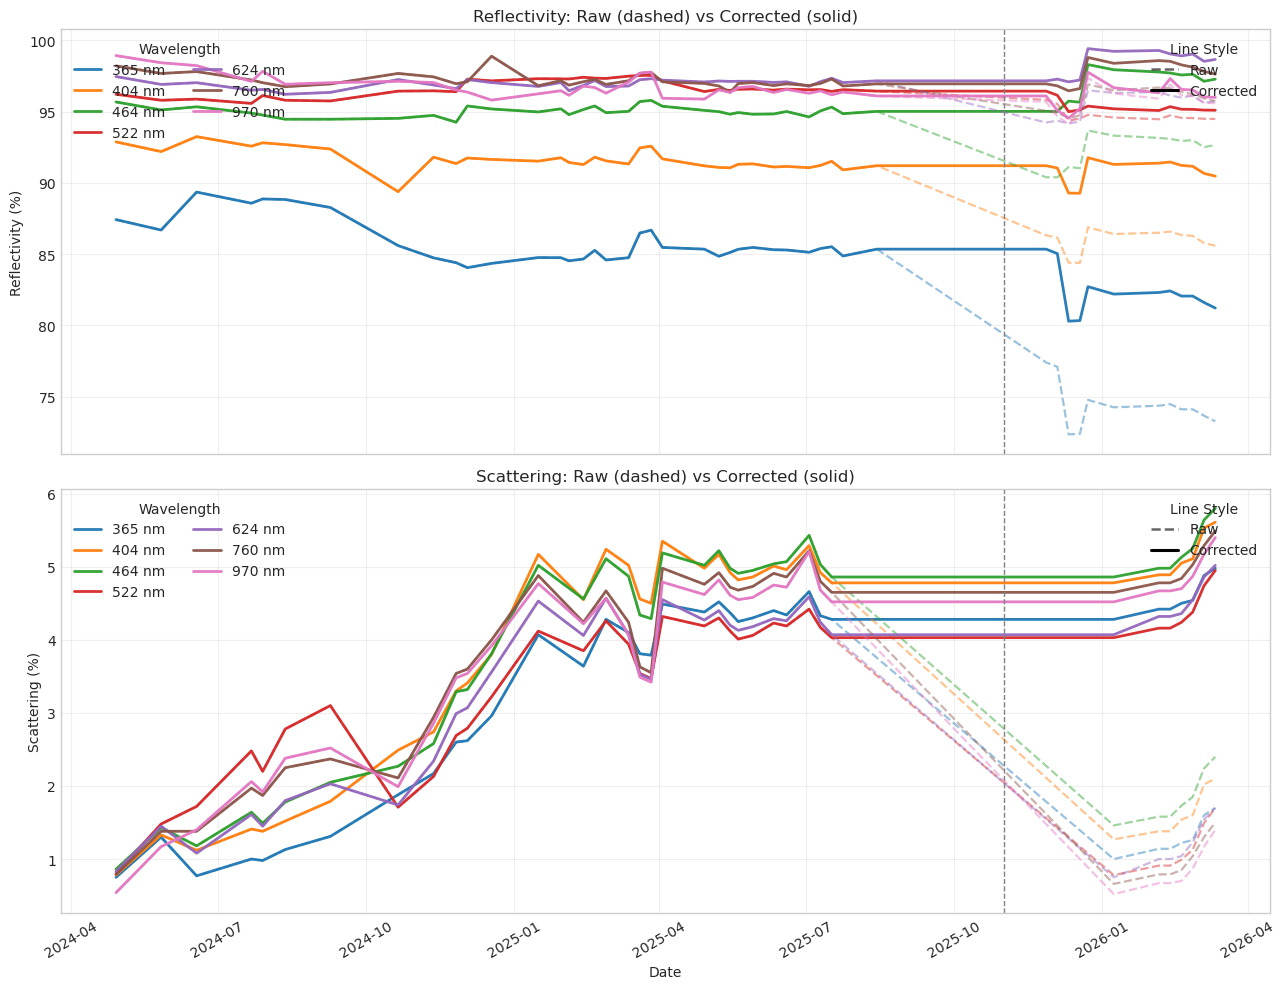

In [21]:
from matplotlib.lines import Line2D



fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)



# Fixed color per wavelength so raw/corrected pairs are easy to compare.

color_map = {wl_col: f'C{i}' for i, wl_col in enumerate(wavelength_cols)}



for wl_col in wavelength_cols:

    label = wl_col.replace('_nm', ' nm')

    color = color_map[wl_col]



    axes[0].plot(

        reflectivity['date'], reflectivity[wl_col],

        linestyle='--', linewidth=1.6, alpha=0.45, color=color

    )

    axes[0].plot(

        reflectivity_corr['date'], reflectivity_corr[wl_col],

        linestyle='-', linewidth=2.0, alpha=0.95, color=color, label=label

    )



    axes[1].plot(

        scattering['date'], scattering[wl_col],

        linestyle='--', linewidth=1.6, alpha=0.45, color=color

    )

    axes[1].plot(

        scattering_corr['date'], scattering_corr[wl_col],

        linestyle='-', linewidth=2.0, alpha=0.95, color=color, label=label

    )



style_handles = [

    Line2D([0], [0], color='black', linestyle='--', linewidth=1.8, alpha=0.6, label='Raw'),

    Line2D([0], [0], color='black', linestyle='-', linewidth=2.2, label='Corrected'),

]



for ax, title, ylabel in [

    (axes[0], 'Reflectivity: Raw (dashed) vs Corrected (solid)', 'Reflectivity (%)'),

    (axes[1], 'Scattering: Raw (dashed) vs Corrected (solid)', 'Scattering (%)'),

]:

    ax.axvline(post_window_start, color='gray', linestyle='--', linewidth=1)

    ax.set_title(title)

    ax.set_ylabel(ylabel)

    ax.grid(True, alpha=0.3)



    wl_legend = ax.legend(title='Wavelength', ncols=2, loc='upper left')

    style_legend = ax.legend(handles=style_handles, title='Line Style', loc='upper right')

    ax.add_artist(wl_legend)



axes[1].set_xlabel('Date')

plt.xticks(rotation=30)

plt.tight_layout()

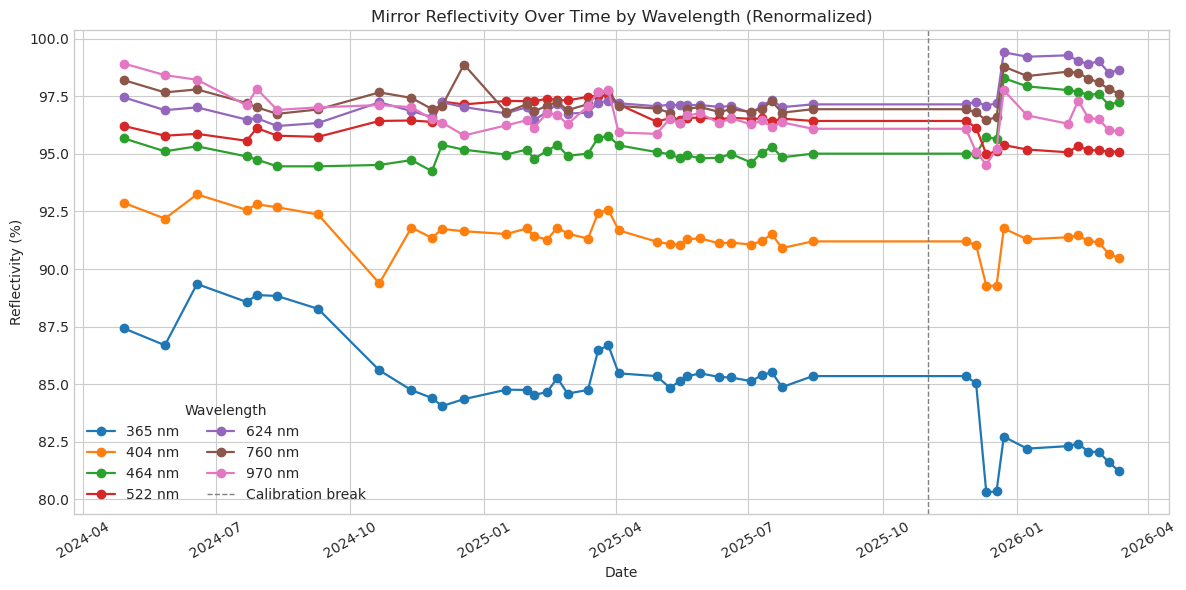

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

for wl, g in reflectivity_long.groupby('wavelength_nm'):

    ax.plot(g['date'], g['reflectivity_pct_corr'], marker='o', linewidth=1.6, label=f'{wl} nm')



ax.set_title('Mirror Reflectivity Over Time by Wavelength (Renormalized)')

ax.set_xlabel('Date')

ax.set_ylabel('Reflectivity (%)')

ax.axvline(pd.Timestamp('2025-11-01'), color='gray', linestyle='--', linewidth=1, label='Calibration break')

ax.legend(title='Wavelength', ncols=2)

plt.xticks(rotation=30)

plt.tight_layout()

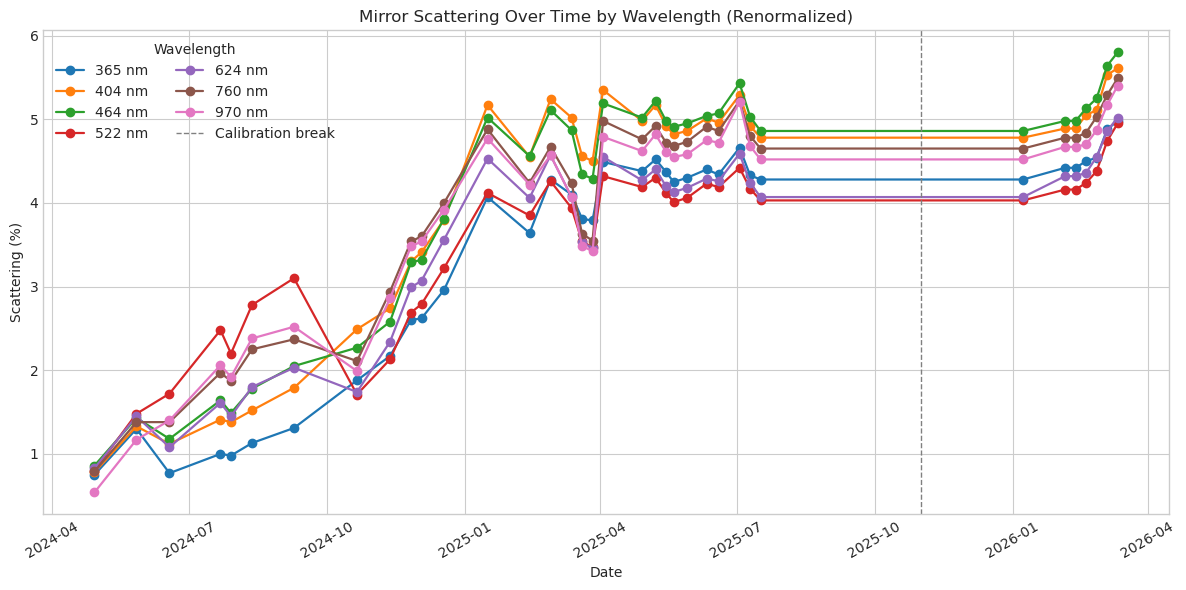

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

for wl, g in scattering_long.groupby('wavelength_nm'):

    ax.plot(g['date'], g['scattering_pct_corr'], marker='o', linewidth=1.6, label=f'{wl} nm')



ax.set_title('Mirror Scattering Over Time by Wavelength (Renormalized)')

ax.set_xlabel('Date')

ax.set_ylabel('Scattering (%)')

ax.axvline(pd.Timestamp('2025-11-01'), color='gray', linestyle='--', linewidth=1, label='Calibration break')

ax.legend(title='Wavelength', ncols=2)

plt.xticks(rotation=30)

plt.tight_layout()

In [24]:
summary = reflectivity_corr.set_index('date')[wavelength_cols].mean().to_frame('mean_reflectivity_pct_corr')

summary['mean_scattering_pct_corr'] = scattering_corr.set_index('date')[wavelength_cols].mean()

summary.index.name = 'wavelength'

summary

,mean_reflectivity_pct_corr,mean_scattering_pct_corr
wavelength,,
365_nm,84.863043,3.430556
404_nm,91.441087,4.028611
464_nm,95.498261,4.061944
522_nm,96.318043,3.527222
624_nm,97.331739,3.523611
760_nm,97.322826,3.930556
970_nm,96.624348,3.838056


## Effective Observing Efficiency ($R(1-S)$)

This section computes a simple per-wavelength efficiency proxy using corrected values:

- $R$ = reflectivity (fraction)
- $S$ = scattering (fraction)
- Efficiency proxy = $R(1-S)$

Interpretation: higher is better for preserving useful light in the image core while limiting scattered halo contribution.

,date,efficiency_mean_pct,365_nm_eff,404_nm_eff,464_nm_eff,522_nm_eff,624_nm_eff,760_nm_eff,970_nm_eff
28,2025-07-17,90.02092,0.818597,0.871358,0.906779,0.925247,0.933687,0.927565,0.918231
29,2026-01-08,90.202888,0.786818,0.869263,0.931706,0.913538,0.951817,0.938053,0.923005
30,2026-02-05,90.037334,0.786719,0.869115,0.929011,0.911151,0.949911,0.938584,0.918123
31,2026-02-12,90.187268,0.78777,0.869876,0.928345,0.913739,0.947615,0.938107,0.927656
32,2026-02-19,89.824989,0.783673,0.866134,0.925552,0.911252,0.94588,0.935137,0.920122
33,2026-02-26,89.68761,0.783345,0.865017,0.924855,0.909824,0.945241,0.931751,0.9181
34,2026-03-05,88.991665,0.776274,0.856465,0.916424,0.905923,0.937319,0.926359,0.910652
35,2026-03-12,88.763748,0.771752,0.853946,0.916283,0.90383,0.936978,0.922607,0.908065


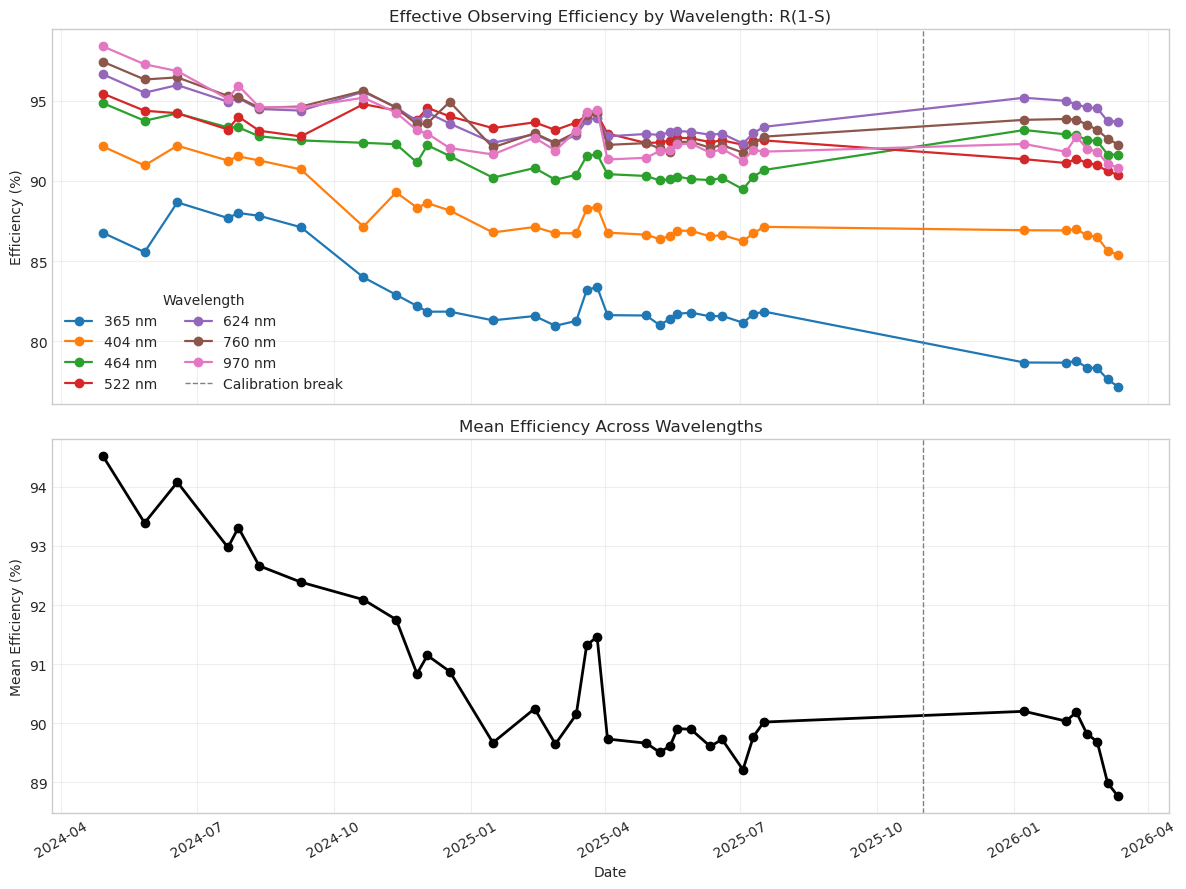

In [25]:
# Inner-join dates available in both corrected tables for a direct comparison.

eff = reflectivity_corr[['date', *wavelength_cols]].merge(

    scattering_corr[['date', *wavelength_cols]],

    on='date',

    suffixes=('_R', '_S'),

)



# Efficiency proxy per wavelength in fraction and percent.

for wl_col in wavelength_cols:

    R = eff[f'{wl_col}_R'] / 100.0

    S = eff[f'{wl_col}_S'] / 100.0

    eff[f'{wl_col}_eff'] = R * (1.0 - S)



eff_cols = [f'{c}_eff' for c in wavelength_cols]

eff['efficiency_mean_pct'] = eff[eff_cols].mean(axis=1) * 100.0



eff_long = eff.melt(

    id_vars='date',

    value_vars=eff_cols,

    var_name='wavelength_eff',

    value_name='efficiency_frac',

)

eff_long['wavelength_nm'] = eff_long['wavelength_eff'].str.replace('_nm_eff', '', regex=False).astype(int)

eff_long['efficiency_pct'] = eff_long['efficiency_frac'] * 100.0



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)



for wl, g in eff_long.groupby('wavelength_nm'):

    ax1.plot(g['date'], g['efficiency_pct'], marker='o', linewidth=1.6, label=f'{wl} nm')



ax1.set_title('Effective Observing Efficiency by Wavelength: R(1-S)')

ax1.set_ylabel('Efficiency (%)')

ax1.axvline(pd.Timestamp('2025-11-01'), color='gray', linestyle='--', linewidth=1, label='Calibration break')

ax1.legend(title='Wavelength', ncols=2)

ax1.grid(True, alpha=0.3)



ax2.plot(eff['date'], eff['efficiency_mean_pct'], color='black', marker='o', linewidth=2)

ax2.set_title('Mean Efficiency Across Wavelengths')

ax2.set_xlabel('Date')

ax2.set_ylabel('Mean Efficiency (%)')

ax2.axvline(pd.Timestamp('2025-11-01'), color='gray', linestyle='--', linewidth=1)

ax2.grid(True, alpha=0.3)



plt.xticks(rotation=30)

plt.tight_layout()



eff[['date', 'efficiency_mean_pct', *eff_cols]].tail(8)

## Include M2: Side-by-Side with M1

Loads M2 reflectivity and scattering data, then compares M1 vs M2 trends and efficiency where both measurements exist.

M2 reflectivity additive correction applied: True
M2 scattering additive correction applied: True

M2 additive offset table:


,m2_reflectivity_offset,m2_scattering_offset
wavelength,,
365_nm,-5.01,-0.30
404_nm,-3.97,-0.26
464_nm,-1.35,-0.18
522_nm,-0.05,-0.09
624_nm,0.16,-0.05
760_nm,-0.14,-0.01
970_nm,-1.60,0.04


,date,M1_single_mean_pct,M1_double_mean_pct,M2_single_mean_pct,Rubin_total_mean_pct
0,2024-10-21,92.092157,84.997106,92.121439,78.782464
1,2024-11-12,91.754483,84.351642,92.328098,78.31876
2,2024-11-26,90.838345,82.673802,91.593499,76.139767
3,2024-12-03,91.14816,83.25784,91.852586,76.929812
4,2025-01-16,89.672032,80.56597,92.702475,75.077696
5,2025-02-27,89.649921,80.536812,91.932970,74.447236
6,2025-04-03,89.7341,80.669741,92.553404,75.020724
7,2025-04-29,89.664054,80.543065,92.715937,75.061334
8,2025-05-08,89.511046,80.28484,92.620944,74.780105
9,2025-05-15,89.613781,80.459154,92.295811,74.665037


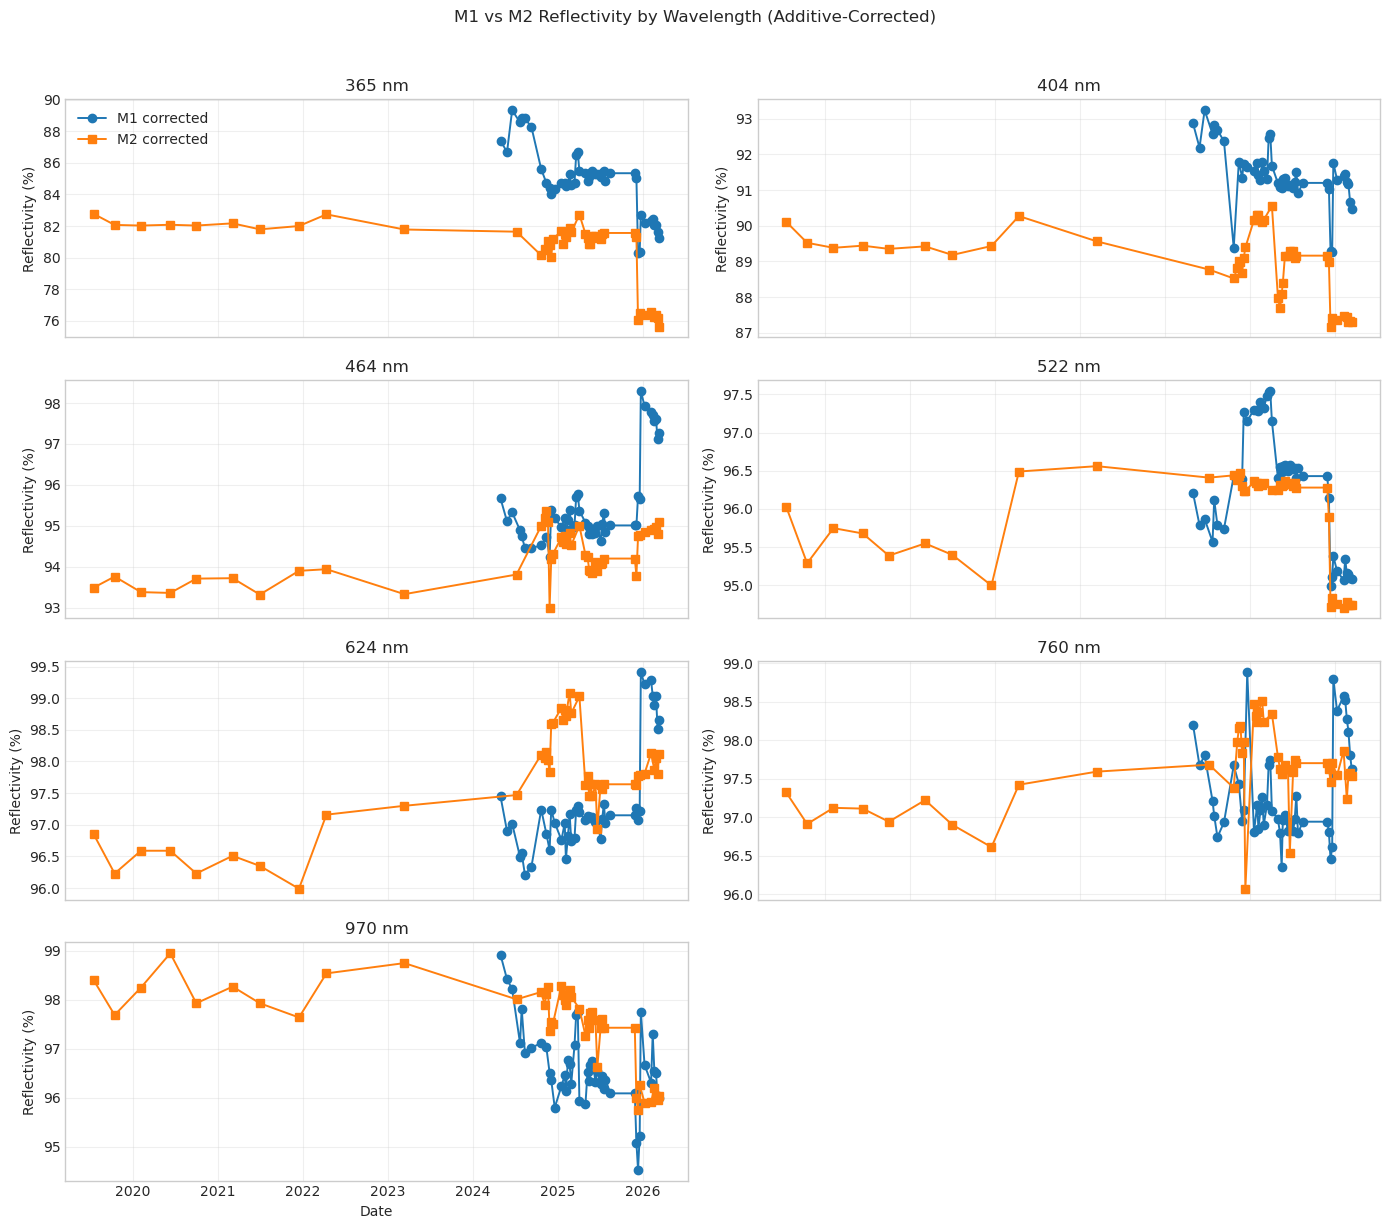

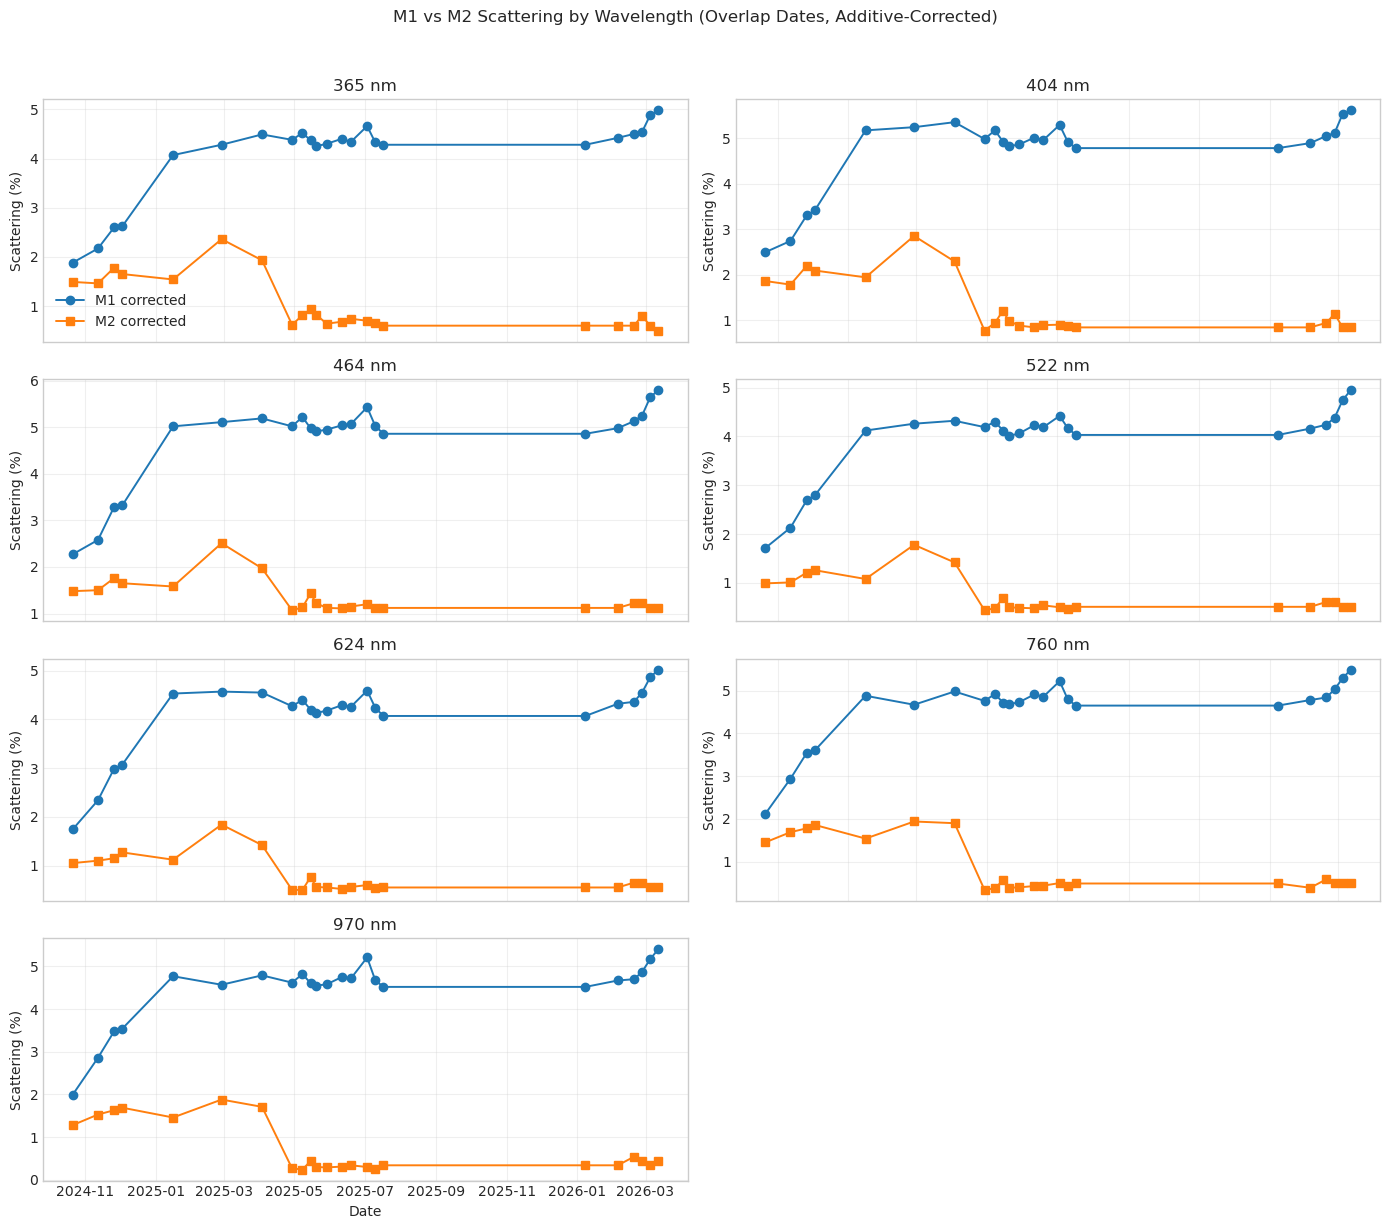

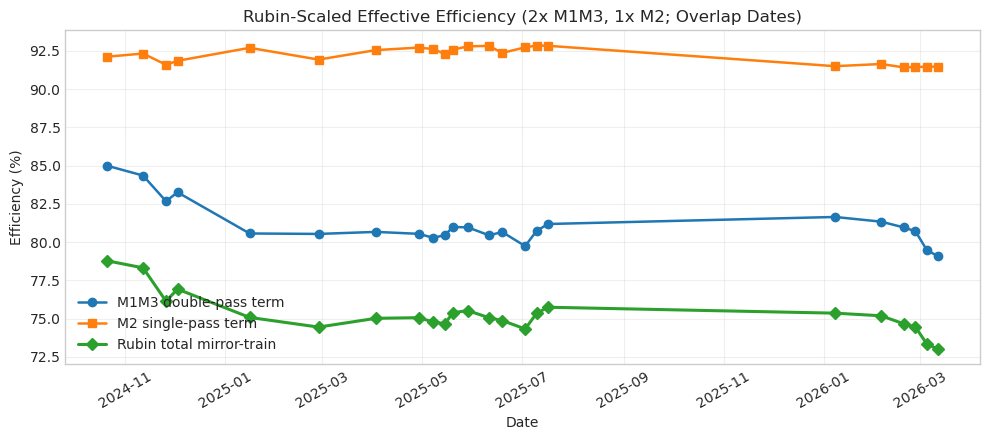

In [39]:
import numpy as np

# Load M2 tables extracted from m2refectivityandscattering.rtf
m2_reflectivity = pd.read_csv('m2_reflectivity.csv')
m2_scattering = pd.read_csv('m2_scattering.csv')
m2_reflectivity['date'] = pd.to_datetime(m2_reflectivity['date'], format='%d-%b-%y')
m2_scattering['date'] = pd.to_datetime(m2_scattering['date'], format='%d-%b-%y')
m2_reflectivity = m2_reflectivity.sort_values('date').reset_index(drop=True)
m2_scattering = m2_scattering.sort_values('date').reset_index(drop=True)

wl_cols = [c for c in m2_reflectivity.columns if c.endswith('_nm')]

def additive_continuity_correction(df, wl_columns, pre_end, post_start):
    corrected = df.copy()
    corrected[wl_columns] = corrected[wl_columns].astype(float)
    pre_mask = corrected['date'] <= pre_end
    post_mask = corrected['date'] >= post_start

    # If both anchor windows exist, apply the same additive continuity method as M1.
    if pre_mask.sum() > 0 and post_mask.sum() > 0:
        pre_anchor = corrected.loc[pre_mask].sort_values('date').iloc[-1]
        post_anchor = corrected.loc[post_mask].sort_values('date').iloc[0]
        offsets = (pre_anchor[wl_columns] - post_anchor[wl_columns]).astype(float)
        corrected.loc[post_mask, wl_columns] = (
            corrected.loc[post_mask, wl_columns].to_numpy(dtype=float) + offsets.to_numpy(dtype=float)
        )
        return corrected, offsets, True

    # Fallback when one side of the break is missing.
    offsets = pd.Series(0.0, index=wl_columns)
    return corrected, offsets, False

m2_reflectivity_corr, m2_ref_offsets, m2_ref_corrected_flag = additive_continuity_correction(
    m2_reflectivity, wl_cols, pre_window_end, post_window_start
)
m2_scattering_corr, m2_sca_offsets, m2_sca_corrected_flag = additive_continuity_correction(
    m2_scattering, wl_cols, pre_window_end, post_window_start
)

m2_offset_table = pd.DataFrame({
    'm2_reflectivity_offset': m2_ref_offsets,
    'm2_scattering_offset': m2_sca_offsets,
})
m2_offset_table.index.name = 'wavelength'

print(f'M2 reflectivity additive correction applied: {m2_ref_corrected_flag}')
print(f'M2 scattering additive correction applied: {m2_sca_corrected_flag}')

# ---------- Reflectivity comparison (M1 corrected vs M2 corrected) ----------
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
for i, wl_col in enumerate(wl_cols):
    ax = axes[i]
    ax.plot(reflectivity_corr['date'], reflectivity_corr[wl_col], marker='o', linewidth=1.4, label='M1 corrected')
    ax.plot(m2_reflectivity_corr['date'], m2_reflectivity_corr[wl_col], marker='s', linewidth=1.4, label='M2 corrected')
    ax.set_title(wl_col.replace('_', ' '))
    ax.set_ylabel('Reflectivity (%)')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

axes[-1].axis('off')
axes[-2].set_xlabel('Date')
plt.suptitle('M1 vs M2 Reflectivity by Wavelength (Additive-Corrected)', y=1.02)
plt.xticks(rotation=30)
plt.tight_layout()

# ---------- Scattering comparison on overlap dates (M1 corrected vs M2 corrected) ----------
m1_sca_overlap = scattering_corr[['date', *wl_cols]].merge(
    m2_scattering_corr[['date', *wl_cols]],
    on='date',
    suffixes=('_M1', '_M2'),
)

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
for i, wl_col in enumerate(wl_cols):
    ax = axes[i]
    ax.plot(m1_sca_overlap['date'], m1_sca_overlap[f'{wl_col}_M1'], marker='o', linewidth=1.4, label='M1 corrected')
    ax.plot(m1_sca_overlap['date'], m1_sca_overlap[f'{wl_col}_M2'], marker='s', linewidth=1.4, label='M2 corrected')
    ax.set_title(wl_col.replace('_', ' '))
    ax.set_ylabel('Scattering (%)')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

axes[-1].axis('off')
axes[-2].set_xlabel('Date')
plt.suptitle('M1 vs M2 Scattering by Wavelength (Overlap Dates, Additive-Corrected)', y=1.02)
plt.xticks(rotation=30)
plt.tight_layout()

# ---------- Rubin-scaled efficiency on overlap ----------
# Rubin light path includes two M1M3 reflections and one M2 reflection.
eff_comp = pd.DataFrame({'date': m1_sca_overlap['date']})
for wl_col in wl_cols:
    m1_R = reflectivity_corr.set_index('date').reindex(m1_sca_overlap['date'])[wl_col].values / 100.0
    m2_R = m2_reflectivity_corr.set_index('date').reindex(m1_sca_overlap['date'])[wl_col].values / 100.0
    m1_S = m1_sca_overlap[f'{wl_col}_M1'].values / 100.0
    m2_S = m1_sca_overlap[f'{wl_col}_M2'].values / 100.0

    m1_single = m1_R * (1 - m1_S)
    m2_single = m2_R * (1 - m2_S)

    eff_comp[f'{wl_col}_M1_single'] = m1_single
    eff_comp[f'{wl_col}_M1_double'] = m1_single ** 2
    eff_comp[f'{wl_col}_M2_single'] = m2_single
    eff_comp[f'{wl_col}_rubin_total'] = (m1_single ** 2) * m2_single

m1_single_cols = [f'{c}_M1_single' for c in wl_cols]
m1_double_cols = [f'{c}_M1_double' for c in wl_cols]
m2_single_cols = [f'{c}_M2_single' for c in wl_cols]
rubin_total_cols = [f'{c}_rubin_total' for c in wl_cols]

eff_comp['M1_single_mean_pct'] = eff_comp[m1_single_cols].mean(axis=1) * 100.0
eff_comp['M1_double_mean_pct'] = eff_comp[m1_double_cols].mean(axis=1) * 100.0
eff_comp['M2_single_mean_pct'] = eff_comp[m2_single_cols].mean(axis=1) * 100.0
eff_comp['Rubin_total_mean_pct'] = eff_comp[rubin_total_cols].mean(axis=1) * 100.0

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(eff_comp['date'], eff_comp['M1_double_mean_pct'], marker='o', linewidth=1.8, label='M1M3 double-pass term')
ax.plot(eff_comp['date'], eff_comp['M2_single_mean_pct'], marker='s', linewidth=1.8, label='M2 single-pass term')
ax.plot(eff_comp['date'], eff_comp['Rubin_total_mean_pct'], marker='D', linewidth=2.2, label='Rubin total mirror-train')
ax.set_title('Rubin-Scaled Effective Efficiency (2x M1M3, 1x M2; Overlap Dates)')
ax.set_ylabel('Efficiency (%)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()

print('\nM2 additive offset table:')
display(m2_offset_table)

eff_comp[[
    'date',
    'M1_single_mean_pct',
    'M1_double_mean_pct',
    'M2_single_mean_pct',
    'Rubin_total_mean_pct',
]]

## Environmental Influence on M1M3 Scattering (ESS Data)

This section fetches Environmental Sensor Suite (ESS) data from the EFD and correlates it with M1M3 scattering trends.

**Key sensors:**
- **Particulate matter** (salIndex 127, 128, 129): Dome dust/particulates
- **Humidity** (salIndex 113): M1M3 cell humidity, where high humidity plus dust can promote sticking
- **Air turbulence** (salIndex 110, 123-126): Wind/circulation within dome that can mobilize dust

In [49]:
from lsst_efd_client import EfdClient
from astropy.time import Time

# Initialize EFD client
try:
    efd_client = EfdClient("usdf_efd")
    print("Connected to EFD")
except Exception as e:
    print(f"EFD connection warning: {e}")
    efd_client = None

Connected to EFD


In [66]:
if efd_client is not None:
    # Fetch ESS particulate matter data (dust sensors in dome)
    particulate_indices = {
        127: "Particulate 1",
        128: "Particulate 2",
        129: "Particulate 3",
    }

    # Fetch M1M3 humidity data
    humidity_index = 113  # M1M3 cell

    # Fetch air turbulence data (speed proxy for dust mobilization)
    turbulence_indices = {
        110: "TMA Platform",
        123: "Top Ring -X/-Y",
        124: "Top Ring +X/-Y",
        125: "Top Ring +X/+Y",
        126: "Top Ring -X/+Y",
    }

    # Base time range (matches scattering window) for non-PM channels
    t_start = Time(scattering_corr['date'].min().isoformat(), scale='utc')
    t_end = Time(scattering_corr['date'].max().isoformat(), scale='utc')

    # Dedicated PM range: full calendar year 2026
    pm_start = Time('2026-01-01T00:00:00', scale='utc')
    pm_end = Time('2027-01-01T00:00:00', scale='utc')

    print(f"Querying PM data from {pm_start.iso} to {pm_end.iso}")
    print(f"Querying humidity/turbulence from {t_start.iso} to {t_end.iso}")

    # Fetch particulate data from particleMeasurements (concentration bins 0..4)
    pm_topic = "lsst.sal.ESS.particleMeasurements"
    pm_fields = [
        "numberConcentration0", "numberConcentration1", "numberConcentration2", "numberConcentration3", "numberConcentration4",
        "matterConcentration0", "matterConcentration1", "matterConcentration2", "matterConcentration3", "matterConcentration4",
    ]

    ess_pm_data = {}
    for idx, label in particulate_indices.items():
        try:
            df_pm = await efd_client.select_time_series(
                pm_topic,
                fields=pm_fields,
                start=pm_start,
                end=pm_end,
                index=idx,
            )
            ess_pm_data[idx] = df_pm
            print(f"  [{idx}] {label:20s} topic={pm_topic} rows={len(df_pm)}")
        except Exception as e:
            ess_pm_data[idx] = pd.DataFrame()
            print(f"  [{idx}] {label:20s} particulate fetch error: {e}")

    # Fetch M1M3 relative humidity from ESS.relativeHumidity.relativeHumidityItem
    ess_humidity_data = None
    try:
        df_humidity = await efd_client.select_time_series(
            "lsst.sal.ESS.relativeHumidity",
            fields=["relativeHumidityItem"],
            start=t_start,
            end=t_end,
            index=humidity_index,
        )
        ess_humidity_data = df_humidity
        print(f"M1M3 relative humidity (index={humidity_index}): rows={len(df_humidity)}")
    except Exception as e:
        print(f"M1M3 humidity fetch error: {e}")

    # Fetch air turbulence (speed magnitude proxy)
    ess_turbulence_data = {}
    try:
        for idx, label in turbulence_indices.items():
            df_turb = await efd_client.select_time_series(
                "lsst.sal.ESS.airTurbulence",
                fields=["speedMagnitude"],
                start=t_start,
                end=t_end,
                index=idx,
            )
            ess_turbulence_data[idx] = df_turb
            print(f"  [{idx}] {label:20s}  rows={len(df_turb)}")
    except Exception as e:
        print(f"Air turbulence fetch error: {e}")
else:
    print("Skipping ESS queries (EFD client unavailable)")

Querying PM data from 2026-01-01 00:00:00.000 to 2027-01-01 00:00:00.000
Querying humidity/turbulence from 2024-04-29 00:00:00.000 to 2026-03-12 00:00:00.000
  [127] Particulate 1        topic=lsst.sal.ESS.particleMeasurements rows=704760
  [128] Particulate 2        topic=lsst.sal.ESS.particleMeasurements rows=732338
  [129] Particulate 3        topic=lsst.sal.ESS.particleMeasurements rows=688181
M1M3 relative humidity (index=113): rows=27326862
  [110] TMA Platform          rows=17108923
  [123] Top Ring -X/-Y        rows=685945
  [124] Top Ring +X/-Y        rows=686641
  [125] Top Ring +X/+Y        rows=687288
  [126] Top Ring -X/+Y        rows=687294


PM-Scattering overlap in 2026 (6-hour bins): 6 points

PM total vs Scattering Correlation by Sensor (Pearson):

Humidity-Scattering overlap: 24 days
Humidity vs scattering correlation: +0.038


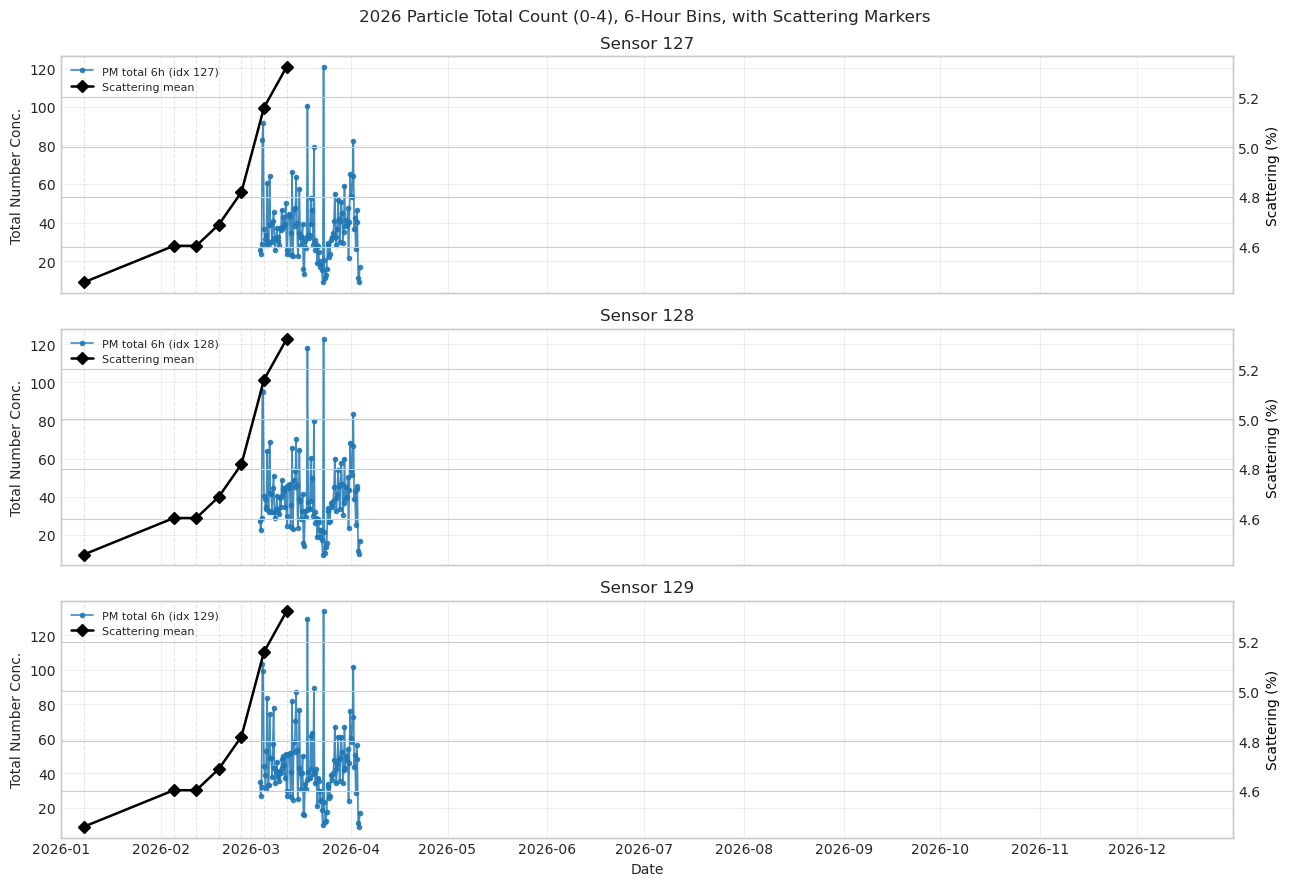

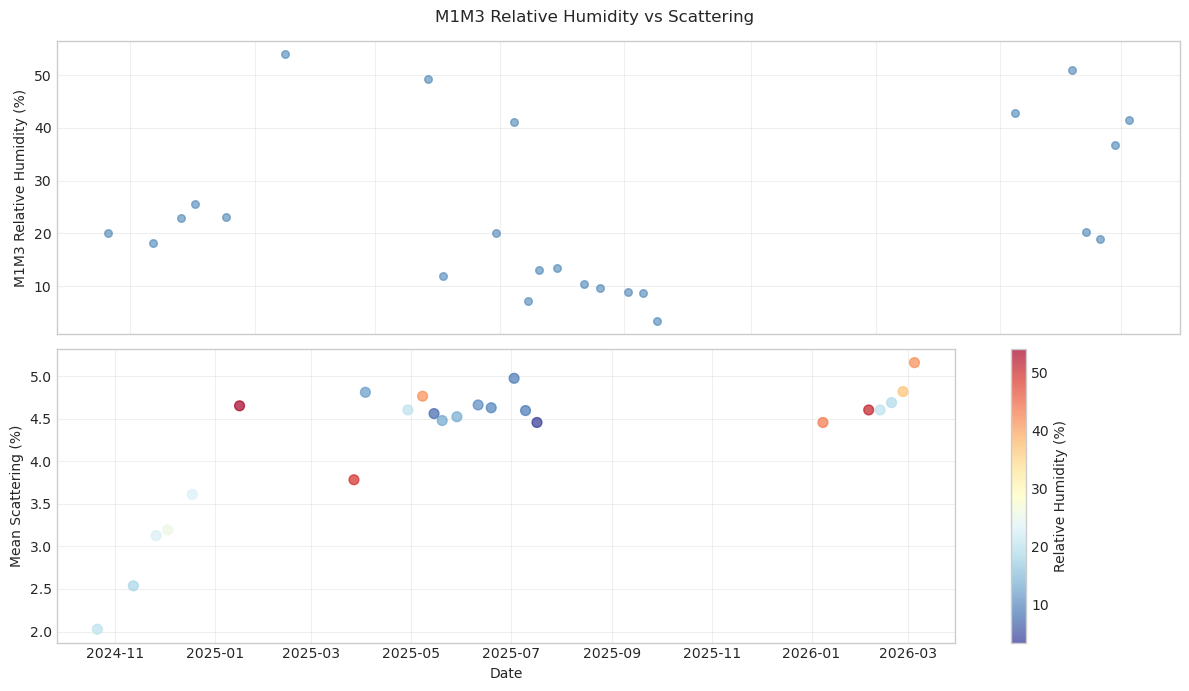

In [67]:
if efd_client is not None and ess_pm_data:
    # 6-hour aggregate of ESS particulate matter
    pm_binned = []
    for idx, df_pm in ess_pm_data.items():
        if df_pm.empty:
            continue

        number_cols = [
            c for c in df_pm.columns
            if c in [
                'numberConcentration0', 'numberConcentration1', 'numberConcentration2',
                'numberConcentration3', 'numberConcentration4',
                'numberConectration0', 'numberConectration1', 'numberConectration2',
                'numberConectration3', 'numberConectration4',
            ]
        ]

        if len(number_cols) < 5:
            continue

        df_pm_copy = df_pm[number_cols].copy()
        df_pm_copy['particle_total_count'] = df_pm_copy[number_cols].sum(axis=1)

        # Bin PM totals to 6-hour means.
        six_hour = (
            df_pm_copy[['particle_total_count']]
            .resample('6h')
            .mean()
            .dropna()
            .reset_index()
            .rename(columns={'index': 'time'})
        )
        six_hour['sensor_idx'] = idx
        pm_binned.append(six_hour)

    if pm_binned:
        pm_all = pd.concat(pm_binned, ignore_index=True)
        pm_all['time'] = pd.to_datetime(pm_all['time'], utc=True)

        # Build scattering series for timeline overlay.
        scattering_series = scattering_corr[['date', *wl_cols]].copy()
        scattering_series['time'] = pd.to_datetime(scattering_series['date'], utc=True)
        scattering_series['scattering_mean'] = scattering_series[wl_cols].mean(axis=1)

        # Restrict view to 2026 only.
        pm_2026 = pm_all[pm_all['time'].dt.year == 2026].copy()
        scattering_2026 = scattering_series[scattering_series['time'].dt.year == 2026].copy()

        if pm_2026.empty or scattering_2026.empty:
            print('No 2026 data overlap window available for PM/scattering plot.')
        else:
            # Overlap table for diagnostics/correlation only (match to nearest 6-hour bin).
            pm_scattering = pd.merge_asof(
                pm_2026.sort_values('time'),
                scattering_2026[['time', 'scattering_mean']].sort_values('time'),
                on='time',
                direction='nearest',
                tolerance=pd.Timedelta('3h')
            ).dropna(subset=['scattering_mean'])

            print(f"PM-Scattering overlap in 2026 (6-hour bins): {len(pm_scattering)} points")

            sensors_to_plot = [127, 128, 129]
            fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(13, 9), sharex=True)
            if len(sensors_to_plot) == 1:
                axes = [axes]

            scatter_times = sorted(scattering_2026['time'].unique())
            scatter_plot = scattering_2026.sort_values('time')

            for sensor_idx, ax in zip(sensors_to_plot, axes):
                subset = pm_2026[pm_2026['sensor_idx'] == sensor_idx].sort_values('time')
                ax.plot(
                    subset['time'],
                    subset['particle_total_count'],
                    marker='o',
                    markersize=3,
                    linewidth=1.2,
                    alpha=0.85,
                    label=f'PM total 6h (idx {sensor_idx})'
                )

                # Mark all scattering measurement times on the shared timeline.
                for t_scatter in scatter_times:
                    ax.axvline(t_scatter, color='gray', linestyle='--', linewidth=0.8, alpha=0.2)

                ax.set_ylabel('Total Number Conc.')
                ax.set_title(f'Sensor {sensor_idx}')
                ax.grid(True, alpha=0.3)

                ax_r = ax.twinx()
                ax_r.plot(
                    scatter_plot['time'],
                    scatter_plot['scattering_mean'],
                    color='black',
                    marker='D',
                    linewidth=1.8,
                    label='Scattering mean'
                )
                ax_r.set_ylabel('Scattering (%)', color='black')

                h1, l1 = ax.get_legend_handles_labels()
                h2, l2 = ax_r.get_legend_handles_labels()
                ax.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)

            axes[-1].set_xlim(pd.Timestamp('2026-01-01', tz='UTC'), pd.Timestamp('2026-12-31', tz='UTC'))
            axes[-1].set_xlabel('Date')
            plt.suptitle('2026 Particle Total Count (0-4), 6-Hour Bins, with Scattering Markers')
            plt.tight_layout()

            if len(pm_scattering) > 2:
                print('\nPM total vs Scattering Correlation by Sensor (Pearson):')
                for sensor_idx in sensors_to_plot:
                    valid = pm_scattering.loc[
                        pm_scattering['sensor_idx'] == sensor_idx,
                        ['particle_total_count', 'scattering_mean']
                    ].dropna()
                    if len(valid) > 2:
                        corr = valid.corr().iloc[0, 1]
                        print(f'  sensor {sensor_idx}: {corr:+.3f}')
            else:
                print('\nNot enough overlap points for stable correlation (need > 2 non-null rows).')
    else:
        print('No particulate concentration data fetched')

if efd_client is not None and ess_humidity_data is not None and not ess_humidity_data.empty:
    # Daily aggregate of M1M3 relative humidity
    hum_col = 'relativeHumidityItem'
    humidity_daily = ess_humidity_data.copy()
    if hum_col not in humidity_daily.columns:
        print(f"Humidity column '{hum_col}' not found in ESS humidity data.")
    else:
        humidity_daily['date'] = pd.to_datetime(humidity_daily.index).date
        humidity_agg = humidity_daily.groupby('date')[[hum_col]].mean().reset_index()

        # Merge with scattering
        scattering_for_hum = scattering_corr[['date', *wl_cols]].copy()
        scattering_for_hum['date'] = pd.to_datetime(scattering_for_hum['date']).dt.date

        hum_scattering = humidity_agg.merge(
            scattering_for_hum,
            on='date',
            how='inner'
        )

        if not hum_scattering.empty:
            print(f"\nHumidity-Scattering overlap: {len(hum_scattering)} days")
            hum_scattering['scattering_mean'] = hum_scattering[wl_cols].mean(axis=1)

            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

            ax1.scatter(hum_scattering['date'], hum_scattering[hum_col], alpha=0.6, s=30, color='steelblue')
            ax1.set_ylabel('M1M3 Relative Humidity (%)')
            ax1.grid(True, alpha=0.3)

            color_scatter = ax2.scatter(
                hum_scattering['date'],
                hum_scattering['scattering_mean'],
                c=hum_scattering[hum_col],
                cmap='RdYlBu_r',
                s=50,
                alpha=0.7
            )
            ax2.set_ylabel('Mean Scattering (%)')
            ax2.set_xlabel('Date')
            cbar = plt.colorbar(color_scatter, ax=ax2)
            cbar.set_label('Relative Humidity (%)')
            ax2.grid(True, alpha=0.3)

            plt.suptitle('M1M3 Relative Humidity vs Scattering')
            plt.tight_layout()

            corr_hum = hum_scattering[[hum_col, 'scattering_mean']].corr().iloc[0, 1]
            print(f"Humidity vs scattering correlation: {corr_hum:+.3f}")

Turbulence-Scattering overlap: 24 days
Air speed median-of-sensors (mean) vs scattering: +0.275
Air speed median-of-sensors (max ) vs scattering: +0.130
Air speed median-of-sensors (std ) vs scattering: +0.246


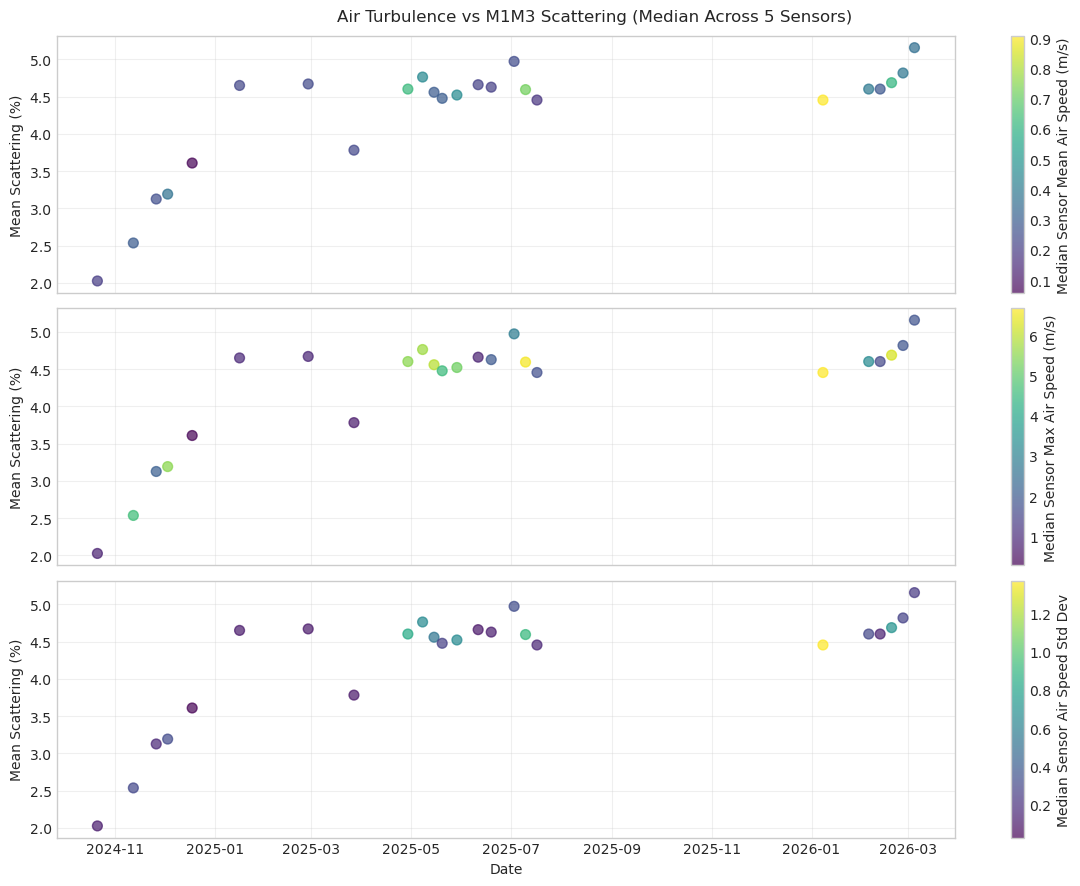

In [68]:
if efd_client is not None and ess_turbulence_data:
    # Daily aggregate of air turbulence (wind speed magnitude)
    turb_daily_list = []
    for sensor_idx, df_turb in ess_turbulence_data.items():
        if df_turb.empty:
            continue
        df_turb_copy = df_turb.copy()
        df_turb_copy['date'] = df_turb_copy.index.date
        daily = df_turb_copy.groupby('date')['speedMagnitude'].agg(['mean', 'max', 'std'])
        daily['sensor_idx'] = sensor_idx
        daily['date'] = daily.index
        turb_daily_list.append(daily.reset_index(drop=True))

    if turb_daily_list:
        turb_daily_all = pd.concat(turb_daily_list, ignore_index=True)
        turb_daily_all['date'] = pd.to_datetime(turb_daily_all['date'])

        # Use median across the 5 turbulence sensors for each day.
        turb_med = turb_daily_all.groupby('date')[['mean', 'max', 'std']].median()
        turb_med['date'] = pd.to_datetime(turb_med.index).date
        turb_med = turb_med.reset_index(drop=True)

        scattering_for_turb = scattering_corr[['date', *wl_cols]].copy()
        scattering_for_turb['date'] = pd.to_datetime(scattering_for_turb['date']).dt.date

        turb_scattering = turb_med.merge(
            scattering_for_turb,
            on='date',
            how='inner'
        )

        if not turb_scattering.empty:
            print(f"Turbulence-Scattering overlap: {len(turb_scattering)} days")
            turb_scattering['scattering_mean'] = turb_scattering[wl_cols].mean(axis=1)

            fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

            for col_idx, (speed_field, ax, ylabel) in enumerate([
                ('mean', axes[0], 'Median Sensor Mean Air Speed (m/s)'),
                ('max', axes[1], 'Median Sensor Max Air Speed (m/s)'),
                ('std', axes[2], 'Median Sensor Air Speed Std Dev'),
            ]):
                color_scatter = ax.scatter(
                    turb_scattering['date'],
                    turb_scattering['scattering_mean'],
                    c=turb_scattering[speed_field],
                    cmap='viridis',
                    s=50,
                    alpha=0.7
                )
                cbar = plt.colorbar(color_scatter, ax=ax)
                cbar.set_label(ylabel)
                ax.set_ylabel('Mean Scattering (%)')
                ax.grid(True, alpha=0.3)

            axes[2].set_xlabel('Date')
            plt.suptitle('Air Turbulence vs M1M3 Scattering (Median Across 5 Sensors)')
            plt.tight_layout()

            for speed_field in ['mean', 'max', 'std']:
                valid = turb_scattering[[speed_field, 'scattering_mean']].dropna()
                if len(valid) > 2:
                    corr = valid.corr().iloc[0, 1]
                    print(f"Air speed median-of-sensors ({speed_field:4s}) vs scattering: {corr:+.3f}")
        else:
            print("No turbulence-scattering overlap found")

Wind speed vs total particle count correlation (2026, no temporal binning):
  sensor 127: n=171691, r=-0.036
  sensor 128: n=185976, r=-0.021
  sensor 129: n=169497, r=-0.031


/lscratch/stalder/tmp/ipykernel_1140383/1000905721.py:156: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  t_astropy = Time(merged['time'].dt.tz_convert('UTC').dt.to_pydatetime())
/lscratch/stalder/tmp/ipykernel_1140383/1000905721.py:156: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  t_astropy = Time(merged['time'].dt.tz_convert('UTC').dt.to_pydatetime())
/lscratch/stalder/tmp/ipykernel_1140383/1000905721.py:156: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retai


Wind speed vs total particle count correlation (2026, night only + dome open):
  sensor 127: n=59906, r=+0.008
  sensor 128: n=66276, r=+0.030
  sensor 129: n=60241, r=-0.012


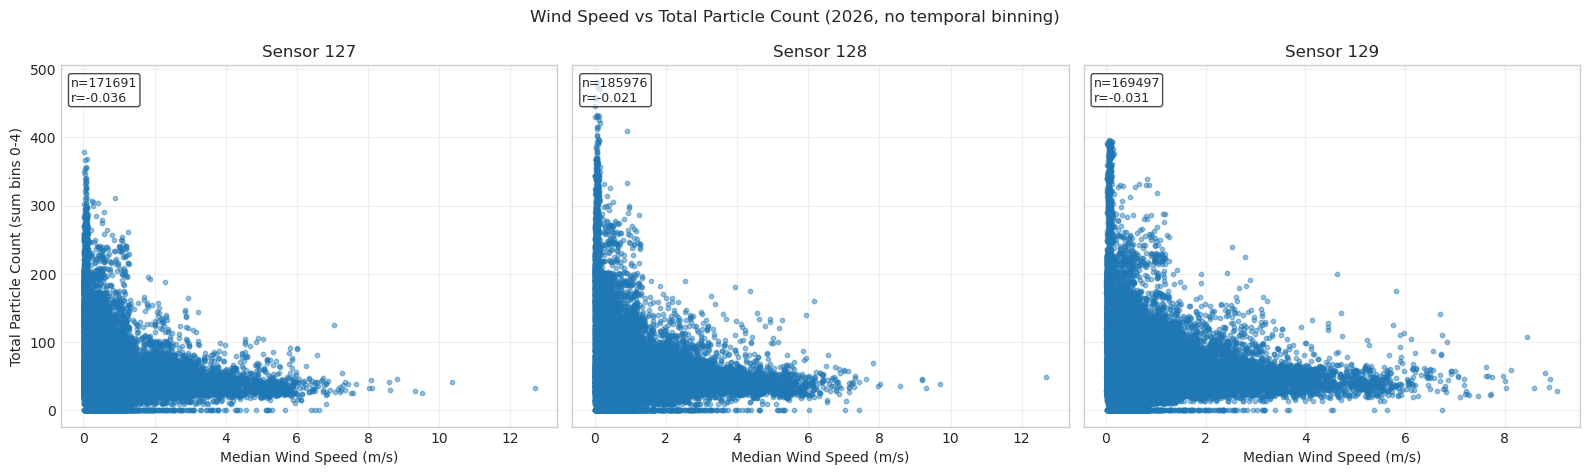

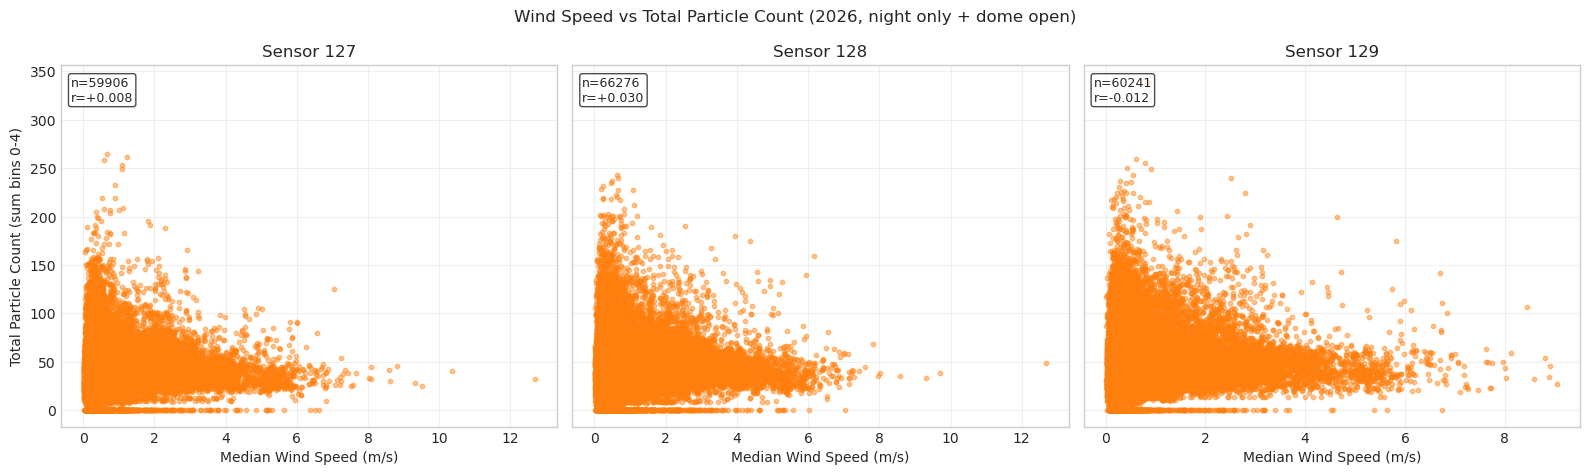

In [71]:
# Build wind-speed median across turbulence sensors with no temporal binning.
wind_raw_parts = []
for sensor_idx, df_turb in ess_turbulence_data.items():
    if df_turb is None or df_turb.empty or 'speedMagnitude' not in df_turb.columns:
        continue

    w = df_turb[['speedMagnitude']].copy().dropna().reset_index()
    w = w.rename(columns={'index': 'time', 'speedMagnitude': 'wind_speed_mps'})
    w['sensor_idx'] = sensor_idx
    wind_raw_parts.append(w)

if not wind_raw_parts:
    print('No turbulence data available for wind/PM correlation.')
else:
    wind_raw_all = pd.concat(wind_raw_parts, ignore_index=True)
    wind_raw_all['time'] = pd.to_datetime(wind_raw_all['time'], utc=True)

    # Median wind speed across the 5 turbulence sensors at each timestamp.
    wind_med = (
        wind_raw_all.groupby('time')['wind_speed_mps']
        .median()
        .reset_index()
        .sort_values('time')
    )

    # Build PM total counts with no temporal binning for each particulate sensor.
    pm_raw_parts = []
    number_candidates = [
        'numberConcentration0', 'numberConcentration1', 'numberConcentration2',
        'numberConcentration3', 'numberConcentration4',
        'numberConectration0', 'numberConectration1', 'numberConectration2',
        'numberConectration3', 'numberConectration4',
    ]

    for pm_idx in [127, 128, 129]:
        df_pm = ess_pm_data.get(pm_idx)
        if df_pm is None or df_pm.empty:
            continue

        number_cols = [c for c in number_candidates if c in df_pm.columns]
        if len(number_cols) < 5:
            continue

        p = df_pm[number_cols].copy()
        p['particle_total_count'] = p[number_cols].sum(axis=1)
        p = p[['particle_total_count']].dropna().reset_index().rename(columns={'index': 'time'})
        p['sensor_idx'] = pm_idx
        pm_raw_parts.append(p)

    if not pm_raw_parts:
        print('No PM data available for wind/PM correlation.')
    else:
        pm_raw_all = pd.concat(pm_raw_parts, ignore_index=True)
        pm_raw_all['time'] = pd.to_datetime(pm_raw_all['time'], utc=True)

        # Focus on 2026 for consistency with the PM plots.
        wind_2026 = wind_med[wind_med['time'].dt.year == 2026].copy()
        pm_2026 = pm_raw_all[pm_raw_all['time'].dt.year == 2026].copy()

        if wind_2026.empty or pm_2026.empty:
            print('No 2026 overlap between wind and PM data.')
        else:
            merged_by_sensor = {}

            fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
            corr_table = []

            for ax, pm_idx in zip(axes, [127, 128, 129]):
                pm_sensor = pm_2026[pm_2026['sensor_idx'] == pm_idx].sort_values('time')

                merged = pd.merge_asof(
                    pm_sensor.sort_values('time'),
                    wind_2026.sort_values('time'),
                    on='time',
                    direction='nearest',
                    tolerance=pd.Timedelta('15min')
                ).dropna(subset=['wind_speed_mps', 'particle_total_count'])

                merged_by_sensor[pm_idx] = merged

                if merged.empty:
                    ax.set_title(f'Sensor {pm_idx} (no overlap)')
                    ax.grid(True, alpha=0.3)
                    corr_table.append((pm_idx, 0, np.nan))
                    continue

                ax.scatter(
                    merged['wind_speed_mps'],
                    merged['particle_total_count'],
                    alpha=0.45,
                    s=10
                )
                ax.set_title(f'Sensor {pm_idx}')
                ax.set_xlabel('Median Wind Speed (m/s)')
                ax.grid(True, alpha=0.3)

                corr_val = merged[['wind_speed_mps', 'particle_total_count']].corr().iloc[0, 1]
                corr_table.append((pm_idx, len(merged), float(corr_val)))
                ax.text(
                    0.02,
                    0.97,
                    f'n={len(merged)}\nr={corr_val:+.3f}',
                    transform=ax.transAxes,
                    va='top',
                    ha='left',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
                )

            axes[0].set_ylabel('Total Particle Count (sum bins 0-4)')
            plt.suptitle('Wind Speed vs Total Particle Count (2026, no temporal binning)')
            plt.tight_layout()

            print('Wind speed vs total particle count correlation (2026, no temporal binning):')
            for pm_idx, npts, rval in corr_table:
                print(f'  sensor {pm_idx}: n={npts}, r={rval:+.3f}')

            # Night + dome-open filter.
            shutter = await efd_client.select_time_series(
                'lsst.sal.MTDome.apertureShutter',
                fields=['positionActual0', 'positionActual1'],
                start=Time('2026-01-01T00:00:00', scale='utc'),
                end=Time('2027-01-01T00:00:00', scale='utc'),
            )
            shutter = shutter[['positionActual0', 'positionActual1']].dropna().reset_index().rename(columns={'index': 'time'})
            shutter['time'] = pd.to_datetime(shutter['time'], utc=True)
            shutter['dome_open'] = (shutter['positionActual0'] > 95.0) & (shutter['positionActual1'] > 95.0)
            shutter = shutter[['time', 'dome_open']].sort_values('time')

            from astropy.coordinates import EarthLocation, AltAz, get_sun
            import astropy.units as u

            rubin_loc = EarthLocation(lat=-30.2444 * u.deg, lon=-70.7494 * u.deg, height=2663 * u.m)

            fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
            corr_table_night = []

            for ax, pm_idx in zip(axes2, [127, 128, 129]):
                merged = merged_by_sensor.get(pm_idx, pd.DataFrame()).copy()
                if merged.empty:
                    ax.set_title(f'Sensor {pm_idx} (no overlap)')
                    ax.grid(True, alpha=0.3)
                    corr_table_night.append((pm_idx, 0, np.nan))
                    continue

                # Nearest shutter state within 2 minutes.
                merged = pd.merge_asof(
                    merged.sort_values('time'),
                    shutter,
                    on='time',
                    direction='nearest',
                    tolerance=pd.Timedelta('2min')
                )

                # Compute sun altitude and filter to nighttime (sun alt < -12 deg).
                t_astropy = Time(merged['time'].dt.tz_convert('UTC').dt.to_pydatetime())
                altaz = AltAz(obstime=t_astropy, location=rubin_loc)
                sun_alt_deg = get_sun(t_astropy).transform_to(altaz).alt.deg
                merged['is_night'] = sun_alt_deg < -12.0

                filtered = merged[(merged['dome_open'] == True) & (merged['is_night'])].dropna(
                    subset=['wind_speed_mps', 'particle_total_count']
                )

                if filtered.empty:
                    ax.set_title(f'Sensor {pm_idx} (no night+dome-open data)')
                    ax.grid(True, alpha=0.3)
                    corr_table_night.append((pm_idx, 0, np.nan))
                    continue

                ax.scatter(
                    filtered['wind_speed_mps'],
                    filtered['particle_total_count'],
                    alpha=0.45,
                    s=10,
                    color='tab:orange'
                )
                ax.set_title(f'Sensor {pm_idx}')
                ax.set_xlabel('Median Wind Speed (m/s)')
                ax.grid(True, alpha=0.3)

                corr_val = filtered[['wind_speed_mps', 'particle_total_count']].corr().iloc[0, 1]
                corr_table_night.append((pm_idx, len(filtered), float(corr_val)))
                ax.text(
                    0.02,
                    0.97,
                    f'n={len(filtered)}\nr={corr_val:+.3f}',
                    transform=ax.transAxes,
                    va='top',
                    ha='left',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
                )

            axes2[0].set_ylabel('Total Particle Count (sum bins 0-4)')
            plt.suptitle('Wind Speed vs Total Particle Count (2026, night only + dome open)')
            plt.tight_layout()

            print('\nWind speed vs total particle count correlation (2026, night only + dome open):')
            for pm_idx, npts, rval in corr_table_night:
                print(f'  sensor {pm_idx}: n={npts}, r={rval:+.3f}')

Outside wind speed vs total particle count (2026, no temporal binning):
  sensor 127: n=704760, r=-0.123
  sensor 128: n=732338, r=-0.108
  sensor 129: n=688181, r=-0.109


/lscratch/stalder/tmp/ipykernel_1140383/1600184429.py:144: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  t_astropy = Time(np.array(merged['time'].dt.tz_convert('UTC').dt.to_pydatetime()))
/lscratch/stalder/tmp/ipykernel_1140383/1600184429.py:144: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  t_astropy = Time(np.array(merged['time'].dt.tz_convert('UTC').dt.to_pydatetime()))
/lscratch/stalder/tmp/ipykernel_1140383/1600184429.py:144: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of 


Outside wind speed vs total particle count (2026, night only + dome open):
  sensor 127: n=229067, r=-0.018
  sensor 128: n=242890, r=+0.021
  sensor 129: n=222601, r=+0.028


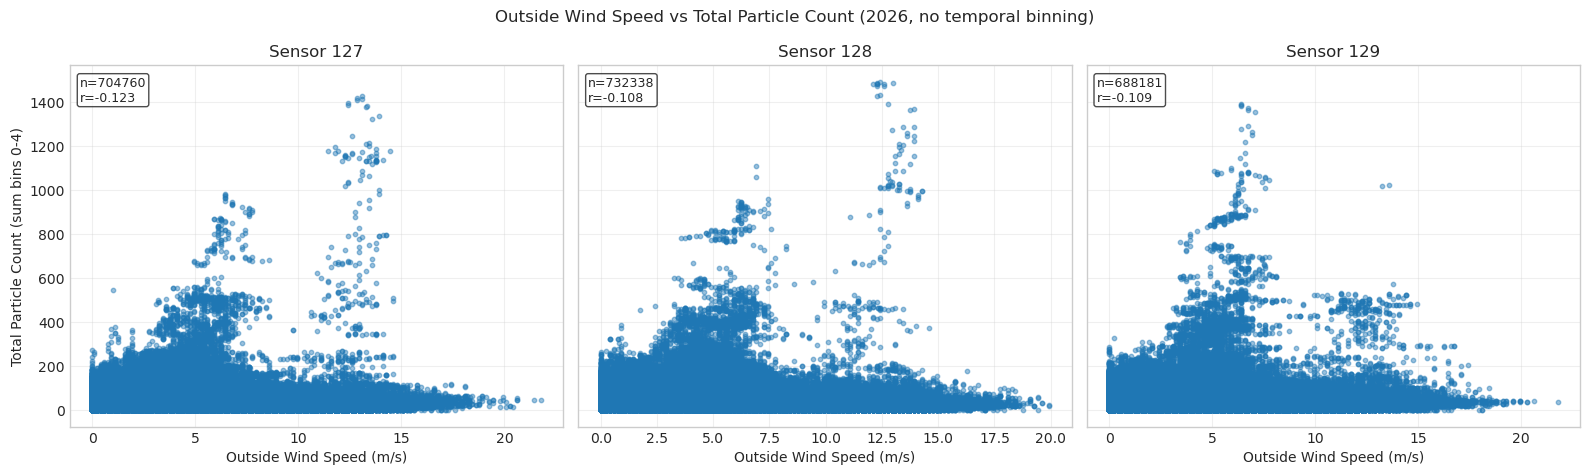

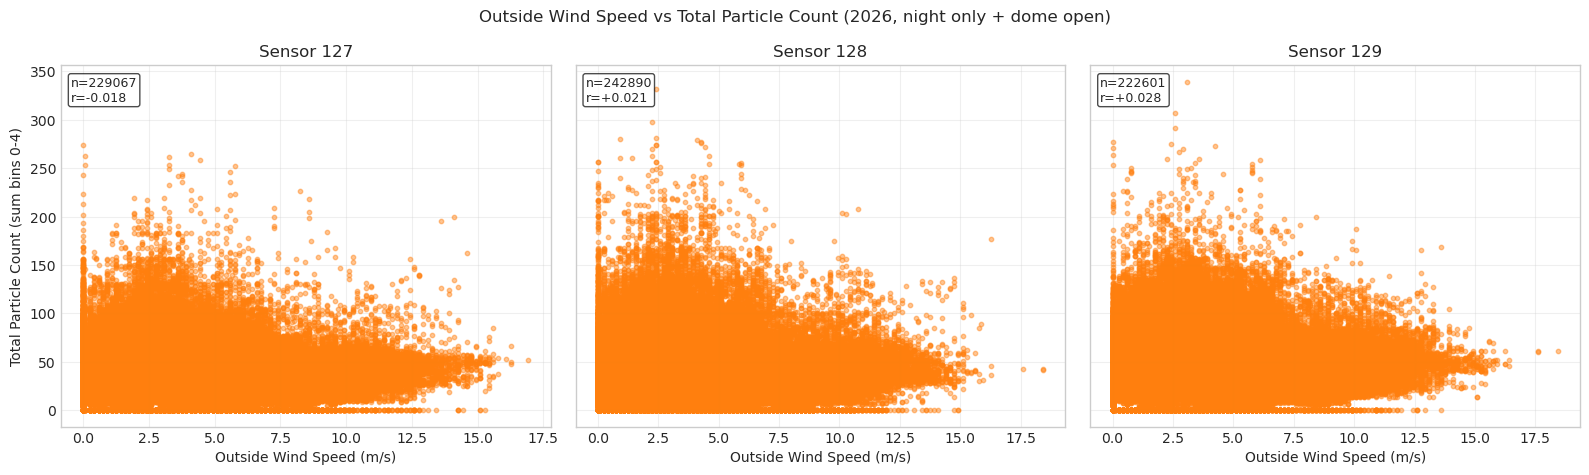

In [72]:
if efd_client is None:
    print('EFD client unavailable; cannot compute outside-wind correlation plots.')
else:
    # Outside wind speed from weather station (ESS airFlow, index 301)
    outside_wind = await efd_client.select_time_series(
        'lsst.sal.ESS.airFlow',
        fields=['speed'],
        start=Time('2026-01-01T00:00:00', scale='utc'),
        end=Time('2027-01-01T00:00:00', scale='utc'),
        index=301,
    )

    if outside_wind is None or outside_wind.empty or 'speed' not in outside_wind.columns:
        print('No outside wind speed data available from ESS.airFlow index=301.')
    else:
        outside_wind = outside_wind[['speed']].dropna().reset_index().rename(
            columns={'index': 'time', 'speed': 'outside_wind_speed_mps'}
        )
        outside_wind['time'] = pd.to_datetime(outside_wind['time'], utc=True)
        outside_wind = outside_wind.sort_values('time')

        # Build PM total counts (no temporal binning) for each particulate sensor.
        pm_raw_parts = []
        number_candidates = [
            'numberConcentration0', 'numberConcentration1', 'numberConcentration2',
            'numberConcentration3', 'numberConcentration4',
            'numberConectration0', 'numberConectration1', 'numberConectration2',
            'numberConectration3', 'numberConectration4',
        ]

        for pm_idx in [127, 128, 129]:
            df_pm = ess_pm_data.get(pm_idx)
            if df_pm is None or df_pm.empty:
                continue

            number_cols = [c for c in number_candidates if c in df_pm.columns]
            if len(number_cols) < 5:
                continue

            p = df_pm[number_cols].copy()
            p['particle_total_count'] = p[number_cols].sum(axis=1)
            p = p[['particle_total_count']].dropna().reset_index().rename(columns={'index': 'time'})
            p['sensor_idx'] = pm_idx
            pm_raw_parts.append(p)

        if not pm_raw_parts:
            print('No PM data available for outside-wind correlation.')
        else:
            pm_raw_all = pd.concat(pm_raw_parts, ignore_index=True)
            pm_raw_all['time'] = pd.to_datetime(pm_raw_all['time'], utc=True)
            pm_2026 = pm_raw_all[pm_raw_all['time'].dt.year == 2026].copy()

            merged_by_sensor = {}

            fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
            corr_table = []

            for ax, pm_idx in zip(axes, [127, 128, 129]):
                pm_sensor = pm_2026[pm_2026['sensor_idx'] == pm_idx].sort_values('time')

                merged = pd.merge_asof(
                    pm_sensor,
                    outside_wind,
                    on='time',
                    direction='nearest',
                    tolerance=pd.Timedelta('15min')
                ).dropna(subset=['outside_wind_speed_mps', 'particle_total_count'])

                merged_by_sensor[pm_idx] = merged

                if merged.empty:
                    ax.set_title(f'Sensor {pm_idx} (no overlap)')
                    ax.grid(True, alpha=0.3)
                    corr_table.append((pm_idx, 0, np.nan))
                    continue

                ax.scatter(
                    merged['outside_wind_speed_mps'],
                    merged['particle_total_count'],
                    alpha=0.45,
                    s=10
                )
                ax.set_title(f'Sensor {pm_idx}')
                ax.set_xlabel('Outside Wind Speed (m/s)')
                ax.grid(True, alpha=0.3)

                corr_val = merged[['outside_wind_speed_mps', 'particle_total_count']].corr().iloc[0, 1]
                corr_table.append((pm_idx, len(merged), float(corr_val)))
                ax.text(
                    0.02,
                    0.97,
                    f'n={len(merged)}\nr={corr_val:+.3f}',
                    transform=ax.transAxes,
                    va='top',
                    ha='left',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
                )

            axes[0].set_ylabel('Total Particle Count (sum bins 0-4)')
            plt.suptitle('Outside Wind Speed vs Total Particle Count (2026, no temporal binning)')
            plt.tight_layout()

            print('Outside wind speed vs total particle count (2026, no temporal binning):')
            for pm_idx, npts, rval in corr_table:
                print(f'  sensor {pm_idx}: n={npts}, r={rval:+.3f}')

            # Night + dome-open filter.
            shutter = await efd_client.select_time_series(
                'lsst.sal.MTDome.apertureShutter',
                fields=['positionActual0', 'positionActual1'],
                start=Time('2026-01-01T00:00:00', scale='utc'),
                end=Time('2027-01-01T00:00:00', scale='utc'),
            )
            shutter = shutter[['positionActual0', 'positionActual1']].dropna().reset_index().rename(columns={'index': 'time'})
            shutter['time'] = pd.to_datetime(shutter['time'], utc=True)
            shutter['dome_open'] = (shutter['positionActual0'] > 95.0) & (shutter['positionActual1'] > 95.0)
            shutter = shutter[['time', 'dome_open']].sort_values('time')

            from astropy.coordinates import EarthLocation, AltAz, get_sun
            import astropy.units as u

            rubin_loc = EarthLocation(lat=-30.2444 * u.deg, lon=-70.7494 * u.deg, height=2663 * u.m)

            fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
            corr_table_night = []

            for ax, pm_idx in zip(axes2, [127, 128, 129]):
                merged = merged_by_sensor.get(pm_idx, pd.DataFrame()).copy()
                if merged.empty:
                    ax.set_title(f'Sensor {pm_idx} (no overlap)')
                    ax.grid(True, alpha=0.3)
                    corr_table_night.append((pm_idx, 0, np.nan))
                    continue

                merged = pd.merge_asof(
                    merged.sort_values('time'),
                    shutter,
                    on='time',
                    direction='nearest',
                    tolerance=pd.Timedelta('2min')
                )

                t_astropy = Time(np.array(merged['time'].dt.tz_convert('UTC').dt.to_pydatetime()))
                altaz = AltAz(obstime=t_astropy, location=rubin_loc)
                sun_alt_deg = get_sun(t_astropy).transform_to(altaz).alt.deg
                merged['is_night'] = sun_alt_deg < -12.0

                filtered = merged[(merged['dome_open'] == True) & (merged['is_night'])].dropna(
                    subset=['outside_wind_speed_mps', 'particle_total_count']
                )

                if filtered.empty:
                    ax.set_title(f'Sensor {pm_idx} (no night+dome-open data)')
                    ax.grid(True, alpha=0.3)
                    corr_table_night.append((pm_idx, 0, np.nan))
                    continue

                ax.scatter(
                    filtered['outside_wind_speed_mps'],
                    filtered['particle_total_count'],
                    alpha=0.45,
                    s=10,
                    color='tab:orange'
                )
                ax.set_title(f'Sensor {pm_idx}')
                ax.set_xlabel('Outside Wind Speed (m/s)')
                ax.grid(True, alpha=0.3)

                corr_val = filtered[['outside_wind_speed_mps', 'particle_total_count']].corr().iloc[0, 1]
                corr_table_night.append((pm_idx, len(filtered), float(corr_val)))
                ax.text(
                    0.02,
                    0.97,
                    f'n={len(filtered)}\nr={corr_val:+.3f}',
                    transform=ax.transAxes,
                    va='top',
                    ha='left',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
                )

            axes2[0].set_ylabel('Total Particle Count (sum bins 0-4)')
            plt.suptitle('Outside Wind Speed vs Total Particle Count (2026, night only + dome open)')
            plt.tight_layout()

            print('\nOutside wind speed vs total particle count (2026, night only + dome open):')
            for pm_idx, npts, rval in corr_table_night:
                print(f'  sensor {pm_idx}: n={npts}, r={rval:+.3f}')

## Outside Wind Speed vs Total Particle Count Correlation

This section repeats the PM correlation analysis using **outside wind speed** from the ESS weather station (`lsst.sal.ESS.airFlow`, `salIndex=301`, field `speed`) instead of inside turbulence sensors.

## Wind Speed vs Total Particle Count Correlation

This block compares 6-hour median wind speed (across ESS turbulence sensors 110, 123, 124, 125, 126) against 6-hour total particle count (sum of number concentration bins 0-4) for particulate sensors 127, 128, and 129.

## 10-Year Recoat Decision (Rubin Total, Recoat M1M3 Only)


This final decision block uses Rubin total mirror-train efficiency and assumes recoating changes only the M1M3 term.




Model assumptions:




1. Total efficiency proxy: `(M1M3_single_pass)^2 * M2_single_pass`


2. Recoating resets only `M1M3_single_pass`; `M2_single_pass` is held fixed at its current overlap-date level


3. Two-month downtime default is preserved and can be changed below

Decision summary (Rubin total, M1M3-only recoat):


,metric,value
0,decision_date,2026-03-12
1,current_m1_single_pct,88.764
2,current_m1_double_pct,79.072
3,current_m2_single_pct,91.477
4,current_total_efficiency_pct,73.001
5,estimated_m1_single_slope_pct_per_month,-0.0184
6,downtime_months,2
7,reset_m1_single_pct,91.086
8,implied_reset_m1_double_pct,82.967
9,break_even_month,40


Sensitivity sample (M1M3 single-pass reset near 90.5%):


,downtime_months,gain_at_m1_single_reset_90p5pct,breakeven_at_m1_single_reset_90p5pct_months
0,0,3.374110,1.0
1,1,2.661083,27.0
2,2,1.947759,52.0
3,3,1.234137,78.0
4,4,0.520216,103.0
5,5,-0.194002,NaN
6,6,-0.908519,NaN


What-if summary (M1M3 single-pass reset = 95%):


,metric,value
0,reset_m1_single_pct,95.000
1,implied_reset_m1_double_pct,90.250
2,downtime_months,2.000
3,break_even_month,16.000
4,10y_cum_no_recoat,84.334
5,10y_cum_recoat,95.185
6,10y_recoat_minus_no_recoat,10.852


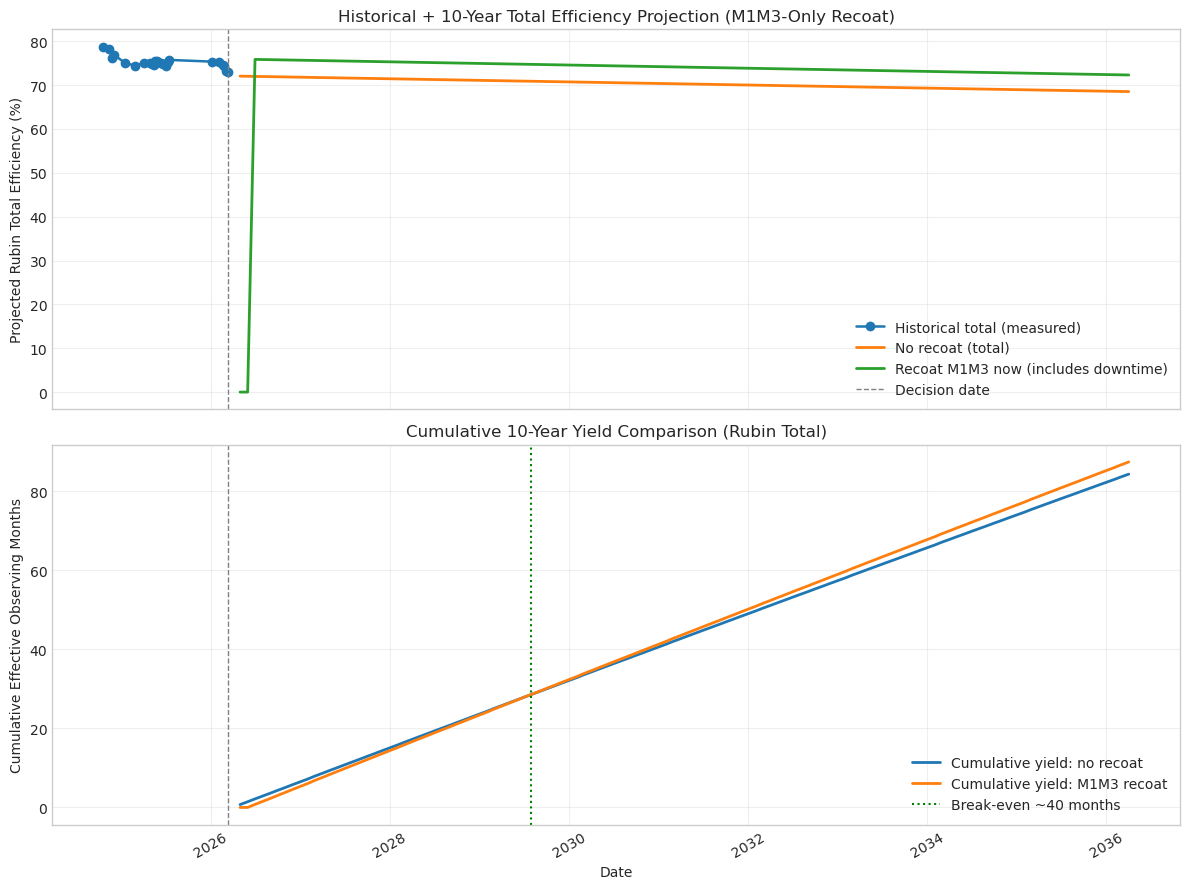

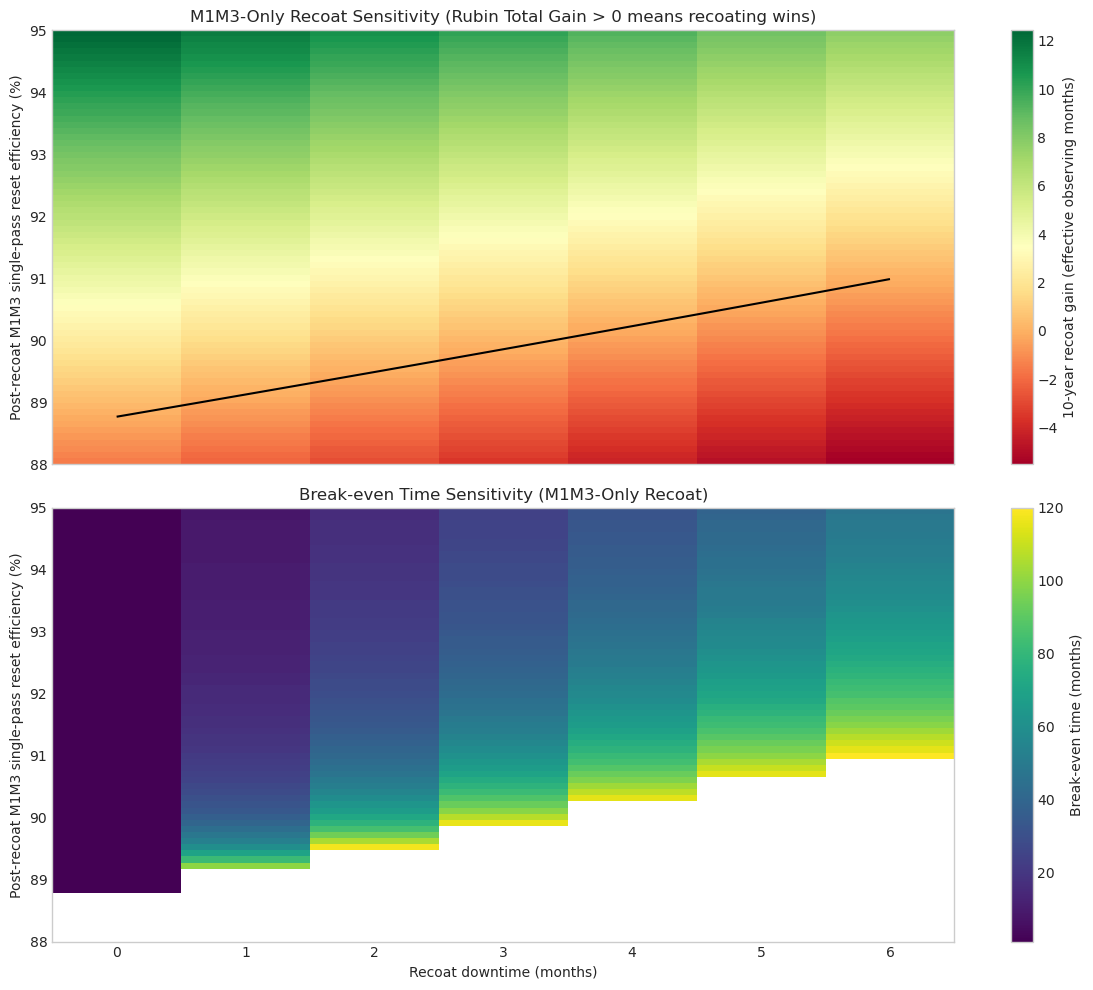

In [43]:
import numpy as np








# -----------------------------






# User-tunable assumptions






# -----------------------------






horizon_years = 10






downtime_months = 2






trend_months_for_slope = 12










# Recoat reset target for M1M3 single-pass term (%).






# Option A: set explicitly in percent units (e.g., 91.5)






reset_m1_single_pct = None






# Option B fallback: historical 90th percentile if None






reset_quantile = 0.90










# Build projection basis from overlap-derived Rubin components






hist = eff_comp[['date', 'M1_single_mean_pct', 'M1_double_mean_pct', 'M2_single_mean_pct', 'Rubin_total_mean_pct']].copy().sort_values('date')






hist['date'] = pd.to_datetime(hist['date'])










# Decision date defaults to latest overlap date






decision_date = hist['date'].max()










m1_single_current_pct = float(hist.loc[hist['date'] == decision_date, 'M1_single_mean_pct'].iloc[0])






m1_double_current_pct = float(hist.loc[hist['date'] == decision_date, 'M1_double_mean_pct'].iloc[0])






m2_current_pct = float(hist.loc[hist['date'] == decision_date, 'M2_single_mean_pct'].iloc[0])






total_current_pct = float(hist.loc[hist['date'] == decision_date, 'Rubin_total_mean_pct'].iloc[0])










# Estimate M1M3 single-pass monthly decline from recent points






recent = hist[hist['date'] >= (decision_date - pd.DateOffset(months=trend_months_for_slope))].copy()






if len(recent) < 3:






    recent = hist.tail(min(10, len(hist))).copy()










x = (recent['date'] - recent['date'].min()).dt.days.values.astype(float) / 30.44






y = pd.to_numeric(recent['M1_single_mean_pct'], errors='coerce').values.astype(float)










if len(y) >= 3 and np.isfinite(y).all():






    slope_m1_single_pct_per_month = np.polyfit(x, y, 1)[0]






else:






    slope_m1_single_pct_per_month = 0.0










if reset_m1_single_pct is None:






    reset_m1_single_pct = float(hist['M1_single_mean_pct'].quantile(reset_quantile))










# Monthly horizon






n_months = int(horizon_years * 12)






future_dates = pd.date_range(decision_date + pd.DateOffset(months=1), periods=n_months, freq='MS')






t = np.arange(1, n_months + 1)










# Scenario A: no recoat -> M1M3 single-pass degrades; M2 held fixed






m1_single_no_recoat_pct = np.clip(m1_single_current_pct + slope_m1_single_pct_per_month * t, 0, 100)






m1_double_no_recoat_pct = np.clip((m1_single_no_recoat_pct ** 2) / 100.0, 0, 100)






total_no_recoat_pct = np.clip((m1_double_no_recoat_pct * m2_current_pct) / 100.0, 0, 100)










# Scenario B: recoat now (M1M3 only) -> downtime then reset+degrade M1M3 single-pass; M2 unchanged






m1_single_recoat_pct = np.zeros(n_months)






for i in range(n_months):






    month_idx = i + 1






    if month_idx <= downtime_months:






        m1_single_recoat_pct[i] = 0.0






    else:






        post = month_idx - downtime_months






        m1_single_recoat_pct[i] = reset_m1_single_pct + slope_m1_single_pct_per_month * post






m1_single_recoat_pct = np.clip(m1_single_recoat_pct, 0, 100)






m1_double_recoat_pct = np.clip((m1_single_recoat_pct ** 2) / 100.0, 0, 100)






total_recoat_pct = np.clip((m1_double_recoat_pct * m2_current_pct) / 100.0, 0, 100)










# Cumulative effective observing yield






cum_no_recoat = np.cumsum(total_no_recoat_pct / 100.0)






cum_recoat = np.cumsum(total_recoat_pct / 100.0)






delta_cum = cum_recoat - cum_no_recoat










break_even_idx = np.where(delta_cum > 0)[0]






break_even_month = int(break_even_idx[0] + 1) if len(break_even_idx) > 0 else None










# Projection plots






fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)










# Historical measured total efficiency for context






ax1.plot(






    hist['date'],






    hist['Rubin_total_mean_pct'],






    marker='o',






    linewidth=1.8,






    linestyle='-',






    label='Historical total (measured)',






)






ax1.plot(future_dates, total_no_recoat_pct, label='No recoat (total)', linewidth=2)






ax1.plot(future_dates, total_recoat_pct, label='Recoat M1M3 now (includes downtime)', linewidth=2)






ax1.axvline(decision_date, color='gray', linestyle='--', linewidth=1, label='Decision date')






ax1.set_ylabel('Projected Rubin Total Efficiency (%)')






ax1.set_title('Historical + 10-Year Total Efficiency Projection (M1M3-Only Recoat)')






ax1.grid(True, alpha=0.3)






ax1.legend()










ax2.plot(future_dates, cum_no_recoat, label='Cumulative yield: no recoat', linewidth=2)






ax2.plot(future_dates, cum_recoat, label='Cumulative yield: M1M3 recoat', linewidth=2)






ax2.axvline(decision_date, color='gray', linestyle='--', linewidth=1)






if break_even_month is not None:






    ax2.axvline(






        future_dates[break_even_month - 1],






        color='green',






        linestyle=':',






        linewidth=1.5,






        label=f'Break-even ~{break_even_month} months',






    )










ax2.set_xlabel('Date')






ax2.set_ylabel('Cumulative Effective Observing Months')






ax2.set_title('Cumulative 10-Year Yield Comparison (Rubin Total)')






ax2.grid(True, alpha=0.3)






ax2.legend()










plt.xticks(rotation=30)






plt.tight_layout()










summary_recoat = pd.DataFrame({






    'metric': [






        'decision_date',






        'current_m1_single_pct',






        'current_m1_double_pct',






        'current_m2_single_pct',






        'current_total_efficiency_pct',






        'estimated_m1_single_slope_pct_per_month',






        'downtime_months',






        'reset_m1_single_pct',






        'implied_reset_m1_double_pct',






        'break_even_month',






        '10y_cum_no_recoat',






        '10y_cum_recoat',






        '10y_recoat_minus_no_recoat',






    ],






    'value': [






        decision_date.date(),






        round(m1_single_current_pct, 3),






        round(m1_double_current_pct, 3),






        round(m2_current_pct, 3),






        round(total_current_pct, 3),






        round(float(slope_m1_single_pct_per_month), 4),






        downtime_months,






        round(reset_m1_single_pct, 3),






        round(float((reset_m1_single_pct ** 2) / 100.0), 3),






        break_even_month,






        round(float(cum_no_recoat[-1]), 3),






        round(float(cum_recoat[-1]), 3),






        round(float(cum_recoat[-1] - cum_no_recoat[-1]), 3),






    ],






})










# -----------------------------






# Sensitivity: downtime vs M1M3 reset level






# -----------------------------






downtime_grid = np.arange(0, 7, 1)               # 0..6 months






reset_grid = np.linspace(88.0, 95.0, 71)         # M1M3 single-pass reset range










gain_grid = np.zeros((len(reset_grid), len(downtime_grid)))






breakeven_grid = np.full((len(reset_grid), len(downtime_grid)), np.nan)










for i, reset_m1 in enumerate(reset_grid):






    for j, down_m in enumerate(downtime_grid):






        m1_single_no = np.clip(m1_single_current_pct + slope_m1_single_pct_per_month * t, 0, 100)






        m1_double_no = np.clip((m1_single_no ** 2) / 100.0, 0, 100)






        total_no = np.clip((m1_double_no * m2_current_pct) / 100.0, 0, 100)










        m1_single_re = np.zeros(n_months)






        for k in range(n_months):






            m = k + 1






            if m <= down_m:






                m1_single_re[k] = 0.0






            else:






                m1_single_re[k] = reset_m1 + slope_m1_single_pct_per_month * (m - down_m)






        m1_single_re = np.clip(m1_single_re, 0, 100)






        m1_double_re = np.clip((m1_single_re ** 2) / 100.0, 0, 100)






        total_re = np.clip((m1_double_re * m2_current_pct) / 100.0, 0, 100)










        cum_no = np.cumsum(total_no / 100.0)






        cum_re = np.cumsum(total_re / 100.0)






        delta = cum_re - cum_no










        gain_grid[i, j] = delta[-1]






        idx = np.where(delta > 0)[0]






        if len(idx) > 0:






            breakeven_grid[i, j] = idx[0] + 1










fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)










im = ax1.imshow(






    gain_grid,






    origin='lower',






    aspect='auto',






    extent=[downtime_grid.min() - 0.5, downtime_grid.max() + 0.5, reset_grid.min(), reset_grid.max()],






    cmap='RdYlGn',






)






cbar = plt.colorbar(im, ax=ax1)






cbar.set_label('10-year recoat gain (effective observing months)')






ax1.contour(downtime_grid, reset_grid, gain_grid, levels=[0.0], colors='black', linewidths=1.5)






ax1.set_title('M1M3-Only Recoat Sensitivity (Rubin Total Gain > 0 means recoating wins)')






ax1.set_ylabel('Post-recoat M1M3 single-pass reset efficiency (%)')






ax1.grid(False)










im2 = ax2.imshow(






    breakeven_grid,






    origin='lower',






    aspect='auto',






    extent=[downtime_grid.min() - 0.5, downtime_grid.max() + 0.5, reset_grid.min(), reset_grid.max()],






    cmap='viridis',






)






cbar2 = plt.colorbar(im2, ax=ax2)






cbar2.set_label('Break-even time (months)')






ax2.set_title('Break-even Time Sensitivity (M1M3-Only Recoat)')






ax2.set_xlabel('Recoat downtime (months)')






ax2.set_ylabel('Post-recoat M1M3 single-pass reset efficiency (%)')






ax2.grid(False)










plt.tight_layout()










ref_idx = np.argmin(np.abs(reset_grid - 90.5))






sensitivity_points = pd.DataFrame({






    'downtime_months': downtime_grid,






    'gain_at_m1_single_reset_90p5pct': [float(gain_grid[ref_idx, j]) for j in range(len(downtime_grid))],






    'breakeven_at_m1_single_reset_90p5pct_months': [breakeven_grid[ref_idx, j] for j in range(len(downtime_grid))],






})










# -----------------------------






# What-if test: set M1M3 single-pass reset to 95%






# -----------------------------






reset_m1_single_pct_test = 95.0










m1_single_no_test = np.clip(m1_single_current_pct + slope_m1_single_pct_per_month * t, 0, 100)






m1_single_re_test = np.zeros(n_months)






for i in range(n_months):






    month_idx = i + 1






    if month_idx <= downtime_months:






        m1_single_re_test[i] = 0.0






    else:






        post = month_idx - downtime_months






        m1_single_re_test[i] = reset_m1_single_pct_test + slope_m1_single_pct_per_month * post






m1_single_re_test = np.clip(m1_single_re_test, 0, 100)










m1_double_no_test = np.clip((m1_single_no_test ** 2) / 100.0, 0, 100)






m1_double_re_test = np.clip((m1_single_re_test ** 2) / 100.0, 0, 100)






total_no_test = np.clip((m1_double_no_test * m2_current_pct) / 100.0, 0, 100)






total_re_test = np.clip((m1_double_re_test * m2_current_pct) / 100.0, 0, 100)










cum_no_test = np.cumsum(total_no_test / 100.0)






cum_re_test = np.cumsum(total_re_test / 100.0)






delta_test = cum_re_test - cum_no_test










idx = np.where(delta_test > 0)[0]






break_even_month_test = int(idx[0] + 1) if len(idx) > 0 else None










what_if_95 = pd.DataFrame({






    'metric': [






        'reset_m1_single_pct',






        'implied_reset_m1_double_pct',






        'downtime_months',






        'break_even_month',






        '10y_cum_no_recoat',






        '10y_cum_recoat',






        '10y_recoat_minus_no_recoat',






    ],






    'value': [






        reset_m1_single_pct_test,






        round(float((reset_m1_single_pct_test ** 2) / 100.0), 3),






        downtime_months,






        break_even_month_test,






        round(float(cum_no_test[-1]), 3),






        round(float(cum_re_test[-1]), 3),






        round(float(delta_test[-1]), 3),






    ],






})










print('Decision summary (Rubin total, M1M3-only recoat):')






display(summary_recoat)










print('Sensitivity sample (M1M3 single-pass reset near 90.5%):')






display(sensitivity_points)










print('What-if summary (M1M3 single-pass reset = 95%):')






what_if_95

Candidate ESS topics:
  lsst.sal.ESS.particleMeasurements
  lsst.sal.ESS.schneiderPm5xxx
HIT topic=lsst.sal.ESS.particleMeasurements index=127 rows=540641 conc_cols=10
  concentration cols: ['matterConcentration0', 'matterConcentration1', 'matterConcentration2', 'matterConcentration3', 'matterConcentration4', 'numberConcentration0', 'numberConcentration1', 'numberConcentration2', 'numberConcentration3', 'numberConcentration4']
HIT topic=lsst.sal.ESS.particleMeasurements index=128 rows=574427 conc_cols=10
  concentration cols: ['matterConcentration0', 'matterConcentration1', 'matterConcentration2', 'matterConcentration3', 'matterConcentration4', 'numberConcentration0', 'numberConcentration1', 'numberConcentration2', 'numberConcentration3', 'numberConcentration4']
HIT topic=lsst.sal.ESS.particleMeasurements index=129 rows=539338 conc_cols=10
  concentration cols: ['matterConcentration0', 'matterConcentration1', 'matterConcentration2', 'matterConcentration3', 'matterConcentration4', 'numb